In [1]:
%cd ../

/nas/zhangtianning.di/projects/unique_data_build


# Build Uparxive Metadata

The metadata for uparxive should shows follow information
- is_the_source_in_clude
    - tex
    - pdf
    - others(html,...)
    - None
- is_the_tex_compilable
    - pass
    - no_root
    - multiroot
    - tikz
    
  



In [2]:
import pandas as pd
import os
import numpy as np
from tqdm.auto import tqdm

### Source associate

#### source_1: already downloaded in public_data/ceph

In [3]:
already_in_ceph_arxivs = dict()
set_for_each_part = {}
for (prefix, source) in [
    ("public_data","/nvme/zhangtianning/datasets/whole_arxiv_data/resource_file_list/whole_file_path_in_arxiv"),
    ("public_data2","/nvme/zhangtianning/datasets/whole_arxiv_data/resource_file_list/arxiv_2301_2309.filelist"),
    ("public_data3","/nvme/zhangtianning/datasets/whole_arxiv_data/resource_file_list/arxiv_2309_2312.filelist"),
    ("local_resource",'/nvme/zhangtianning/datasets/whole_arxiv_data/resource_file_list/extra_download.arxivid'),
    #("public_data_add45w","/nvme/zhangtianning/datasets/whole_arxiv_data/extra_arxiv_tar/add_45w.filelist"),
]:
    set_for_each_part[prefix]={}
    with open(source,'r') as f:
        for line in tqdm(f) :
            dest_name = line.strip()
            size="1"
            if len(dest_name.split())>1:
                    size, dest_name = dest_name.split()
            real_name = os.path.basename(dest_name).replace('.gz', '').replace('.tar', '').replace('.pdf', '')
            if real_name not in already_in_ceph_arxivs:already_in_ceph_arxivs[real_name]=[]
            already_in_ceph_arxivs[real_name].append(os.path.join(prefix,dest_name))
            set_for_each_part[prefix][real_name]=dest_name

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [9]:
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')

In [10]:
len(df)

2451510

In [14]:
passeddf = (df[df['toXML.origin']==True])

In [17]:
arixivid_list = set(passeddf['arxiv_id'])

In [44]:
should_download_part = "/home/zhangtianning.di/tmp/temp/no_base_tex.colorful.filelist"

arixivid_list = []
with open(should_download_part,'r') as f:
    for resource_path in f:
        resource_path = resource_path.strip()
        arixivid = resource_path.split('/')[-2]
        arixivid_list.append(arixivid)

arixivid_list = set(arixivid_list)

In [19]:
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/uparxive_ocr/should_download.arxivids",'w') as f:
    for arxivid in arixivid_list:
        f.write(arxivid+'\n')

In [32]:
# df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')

# filtered_df=df[(df['_type']=='ready_to_process')]
# print(len(filtered_df))

# not_registered_arxivid = set(df[df['_type'].isna()].arxiv_id)
# not_in_ceph_but_should_good = (not_registered_arxivid - set(already_in_ceph_arxivs))
# print(len(not_in_ceph_but_should_good))

In [15]:
# existed_arxivids_position_1 = os.listdir("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex")
# existed_arxivids_position_2 = os.listdir("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_tex/")
# arxivid_in_position_1 = set(existed_arxivids_position_1) & set(filtered_df.arxiv_id)
# arxivid_in_position_2 = set(existed_arxivids_position_2) & set(filtered_df.arxiv_id)
# arxivid_in_both       = arxivid_in_position_1&arxivid_in_position_2
# exclude_arxivids      = set(filtered_df.arxiv_id) - (arxivid_in_position_1|arxivid_in_position_2)
# print(f"num of arxiv project in unprocessed_tex ==> {len(existed_arxivids_position_1)}")
# print(f"num of arxiv project in archive_tex ==> {len(existed_arxivids_position_2)}")
# print(f"registed_arxiv_id in unprocessed_tex ==> {len(arxivid_in_position_1)}")
# print(f"registed_arxiv_id in archive_tex ==> {len(arxivid_in_position_2)}")
# print(f"arxiv both in unprocessed_tex and archieve_tex ==> {len(arxivid_in_both)}")
# print(f"arxiv that not in our tex system ==> {len(exclude_arxivids)}")

In [27]:
# not_registered_arxivpath = [already_in_ceph_arxivs[arxivid] for arxivid in  exclude_arxivids if arxivid in already_in_ceph_arxivs]

NameError: name 'exclude_arxivids' is not defined

In [45]:
# not_registered_arxivpath_in_ceph = [plist for plist in not_registered_arxivpath if not any(['local' in p for p in plist])]

In [20]:
the_path_in_ceph = []
for arxivid in arixivid_list:
    the_path_in_ceph.append(already_in_ceph_arxivs[arxivid])

In [21]:
onlyhavePDFresrouce=[]
not_registered_arxivpath_in_ceph_filelist = {}
for plist in tqdm(the_path_in_ceph):
    newplist = [p for p in plist if not p.endswith('.pdf')]
    if len(newplist) > 1:
        localpist = [p for p in newplist if 'local' in p]
        if len(localpist) >0:
            newplist = localpist
    if len(newplist) > 1:
        localpist = [p for p in newplist if 'add' in p]
        if len(localpist) >0:
            newplist = localpist
    if len(newplist) ==0:
        onlyhavePDFresrouce.append(plist[0].split('/')[-1].replace('.pdf','').replace('.tar','').replace('.gz',''))
        continue
    newplist = newplist[0]
    if 'add_45w' in newplist:
        llll= newplist.split('/')
        reasouce_type = "/".join(llll[0:2])
        remain_path = "/".join(llll[2:])
    else:
        llll= newplist.split('/')
        reasouce_type = "/".join(llll[0:1])
        remain_path = "/".join(llll[1:])
    if reasouce_type not in not_registered_arxivpath_in_ceph_filelist:not_registered_arxivpath_in_ceph_filelist[reasouce_type]=[]
    not_registered_arxivpath_in_ceph_filelist[reasouce_type].append(remain_path)

  0%|          | 0/1284455 [00:00<?, ?it/s]

In [22]:
for key,val in not_registered_arxivpath_in_ceph_filelist.items():
    print(f"{key} ==> {len(val)}") 

public_data ==> 947259
local_resource ==> 142838
public_data/add_45w ==> 138601
public_data2 ==> 28777
public_data3 ==> 26980


In [23]:
ROOT = "/nvme/zhangtianning/datasets/whole_arxiv_data/uparxive_ocr/download_needed_filelist_fold"
for key in ['public_data','public_data2','public_data3','local_resource','public_data/add_45w']:
    filepath = f'{ROOT}/not_registered_arxivpath.{key.replace("/",".")}.filelist'
    if key not in not_registered_arxivpath_in_ceph_filelist:continue
    with open(filepath,'w') as f:
        for path in not_registered_arxivpath_in_ceph_filelist[key]:
            f.write(path+'\n')

In [17]:
ROOT = "/nvme/zhangtianning/datasets/whole_arxiv_data/extra_arxiv_tar/filelist_fold"
for key in ['public_data','public_data2','public_data3','local_resource']:
    
    filepath = f'{ROOT}/not_registered_arxivpath.{key}.split'
    if key not in not_registered_arxivpath_in_ceph_filelist:continue
    wholefiles=not_registered_arxivpath_in_ceph_filelist[key]
    wholefiles_split = np.array_split(wholefiles,100)
    os.makedirs(filepath,exist_ok=True)
    for i,filelist in enumerate(wholefiles_split):
        filepath_final = os.path.join(filepath, f"{i:03d}.filelist")
        with open(filepath_final,'w') as f:
            for path in filelist:
                f.write(path+'\n')


In [ ]:
with open("/nvme/zhangtianning.di/sharefold/whole_arxiv_all_files/not_registered_arxivpath.local.filelist",'w') as f:
    for name in not_registered_arxivpath_in_ceph_filelist['local_resource']:
        f.write(name+'\n')

In [49]:
updated_indices =[ name_to_index[k] for k in onlyhavePDFresrouce if k in not_passed_arxivids]
df.iloc[updated_indices,df.columns.get_loc('_type')]='isPDF'

NameError: name 'df' is not defined

In [162]:
not_registered_arxivpath_in_local = [plist for plist in not_registered_arxivpath if any(['local' in p for p in plist])]
print(len(not_registered_arxivpath_in_local))

3925


In [30]:
not_registered_arxivpath_in_ceph_filelist.keys()

dict_keys(['local_resource', 'public_data'])

In [31]:
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/extra_arxiv_tar/not_registered_arxivpath_in_public.filelist",'w') as f:
    for name in not_registered_arxivpath_in_ceph_filelist['public_data']:
        f.write(name+'\n')

In [166]:
not_registered_arxivpath[2]

['public_data/1702.07825']

In [18]:
not_registered_arxivid_should_download = set(not_registered_arxivid) - set(already_in_ceph_arxivs_set)

In [19]:
len(already_in_ceph_arxivs_set & not_registered_arxivid)

18912

In [20]:
len(already_in_ceph_arxivs_set - not_registered_arxivid)

2430692

In [21]:
len(already_in_ceph_arxivs_set)

2449604

In [22]:
len(not_registered_arxivid_should_download)

0

In [23]:
not_registered_arxivid_should_download

set()

In [231]:
with open('should_download_from_online.arxivids','w') as  f:
    for arxivid in not_registered_arxivid_should_download:
        f.write(arxivid+'\n')

In [215]:
len(not_registered_arxivid_should_download)

18089

##### source2: addtion downloads

In [206]:
dest_name

'solv-int_9802005.tar.gz'

In [205]:
source2 = "/nvme/zhangtianning/datasets/whole_arxiv_data/resource_file_list/extra_download.arxivid.part_A"
with open(source2,'r') as f:
    for line in tqdm(f) :
        dest_name = line.strip()
        size="1"
        if len(dest_name.split())>1:
            size, dest_name = dest_name.split()
        real_name = os.path.basename(dest_name).replace('.tar', '').replace('.pdf', '')
        if real_name not in already_in_ceph_arxivs:already_in_ceph_arxivs[real_name]=[]
        already_in_ceph_arxivs[real_name].append(dest_name)
#already_in_ceph_arxivs_set = set(already_in_ceph_arxivs)

0it [00:00, ?it/s]

### check unexcepted

#### is plaintex but passed for compiled

In [2]:
import pandas as pd
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')
print(len(df))
for key in df.keys():
    if 'Unnamed' in key:df.drop(key, axis=1, inplace=True)

import numpy as np
df['index']=np.arange(len(df))
name_to_index = df[['index','arxiv_id']].set_index('arxiv_id')['index'].to_dict()

2451510


In [3]:
with open("/home/zhangtianning.di/tmp/done_files.colorful.addbbl.2.arxivids",'r') as f:
    name_we_have_now = [t.strip() for t in f]

In [7]:
df_wh_have_now = df.iloc[[name_to_index[t] for t in name_we_have_now]]

In [14]:
import re
def get_date(arxiv_id):
    match = re.search(r"\d{4}", arxiv_id)
    if match:
        # Print the matched pattern
        date = match.group()
    assert date
    return date

In [16]:
import os
wholepath = []
for (_,row) in df_wh_have_now.iterrows():
    arxivid= row['arxiv_id']
    rootfile=row['rootfile']
    path = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_tex.colorful.addbbl",
                        get_date(arxivid),
                        arxivid,rootfile
                       )
    wholepath.append(path)

In [17]:
with open('/home/zhangtianning.di/tmp/done_files.colorful.addbbl.2.filelist','w') as f:
    for line in wholepath:
        f.write(line+'\n')

### rebuild from source

In [32]:
arxiv_metadata = pd.read_json("/nvme/zhangtianning/datasets/whole_arxiv_data/arxiv_metadata_snapshot/20240407/arxiv-metadata-snapshot.json",lines=True)

In [33]:
arxiv_metadata['arxivid'] = [t.replace('/','_') for t in arxiv_metadata.id]

In [35]:
no_metadata_arxivids = ["2401.09755","2402.18611","2403.19993","2403.19875","2403.20115","2403.20120","2403.20253","2403.20145","2403.19675","2403.20099","2403.19710","2403.20131","2403.20152","2403.19692","2403.20189","2403.19846","2403.19686","2403.19849","2403.19716","2403.20301","2403.19751","2403.19768","2403.19828","2403.19760","2403.19722","2403.19832","2403.19835","2403.19857","2403.19752","2403.19781","2403.19701","2403.19912","2403.19754","2403.19659","2403.19921","2403.19810","2403.19788","2403.19793","2403.19777","2403.19816","2403.19824","2403.19872","2403.19930","2403.19924","2403.19871","2403.19909","2403.19881","2403.19885","2403.19933","2403.19972","2403.19937","2403.19775","2403.19876","2403.19947","2403.19962","2403.19942","2403.19733","2403.19951","2403.19986","2403.19998","2403.20050","2403.20060","2403.19971","2403.20134","2403.20089","2403.20058","2403.19943","2403.20053","2403.19989","2403.20257","2403.20093","2403.20259","2403.20207","2403.20299","2403.20289","2403.20114","2403.20148","2403.20280","2403.20228","2403.20240","2403.20294","2403.20168","2403.20272","2403.20237","2403.20276","2403.19673","2403.20221","2403.19741","2403.20263","2403.19952","2403.20293","2403.20181","2403.20277","2403.20038","2403.20023","2403.20009","2403.20302","2403.20098","2403.20130","2403.20188","2403.20291","2403.19743","2403.20119","2403.20284","2403.20251","2403.20121","2403.20285","2403.20203","2403.20069","2403.20011","2403.20325","2403.20162","2403.20200","2403.20070","2403.20265","2403.19968","2403.20192","2403.20311","2403.19682","2403.20055","2403.20101","2403.19953","2403.19994","2403.19697","2403.20111","2403.19959","2403.19665","2403.19688","2403.20127","2403.19664","2403.19770","2403.19693","2403.19815","2403.20057","2403.20040","2403.20065","2403.20155","2403.19980","2403.19936","2403.20005","2403.20214","2403.20234","2403.19895","2403.20049","2403.20170","2403.20268","2403.20258","2403.19905","2403.19938","2403.20096","2403.20260","2403.20178","2403.20061","2403.20244","2403.20028","2403.20067","2403.20164","2403.19977","2403.20108","2403.20118","2403.20010","2403.20026","2403.20073","2403.19691","2403.19667","2403.19699","2403.19694","2403.20013","2403.20072","2403.19954","2403.19958","2403.19707","2403.19666","2403.19817","2403.19671","2403.19761","2403.19960","2403.19747","2403.19709","2403.20175","2403.19914","2403.20123","2403.19836","2403.19979","2403.20021","2403.19719","2403.20034","2403.19698","2403.20140","2403.20076","2403.20236","2403.19725","2403.19868","2403.19825","2403.19794","2403.20323","2403.19800","2403.20328","2403.19975","2403.19990","2403.20292","2403.19934","2403.19784","2403.20250","2403.19906","2403.19778","2403.19684","2403.19880","2403.20171","2403.20147","2403.20094","2403.19755","2403.20106","2403.20001","2403.20015","2403.20042","2403.19997","2403.20321","2403.20000","2403.19799","2403.19801","2403.19889","2403.19809","2403.20117","2403.19670","2403.19956","2403.20129","2403.20324","2403.20195","2403.20249","2403.20113","2403.20269","2403.19870","2403.19856","2403.19894","2403.20036","2403.20219","2403.20044","2403.19887","2403.20083","2403.19703","2403.20298","2403.19740","2403.20278","2403.19839","2403.20146","2403.19813","2403.19756","2403.20037"]

In [36]:
no_metadata_arxivids=set(no_metadata_arxivids)

In [38]:
arxiv_metadata[arxiv_metadata['arxivid']=='2403.20113']

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,authors_parsed,year,month,day,arxivid


In [34]:
len(arxiv_metadata)

2450893

In [236]:
import re,json
for title, abstract, arxivid in tqdm(arxiv_metadata[['title','abstract','arxivid']].values):
    match = re.search(r"\d{4}", arxivid)
    if match:
        # Print the matched pattern
        date = match.group()
    ROOT = '/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/metadatas'
    metadatadir = os.path.join(ROOT,date,arxivid)
    os.makedirs(metadatadir, exist_ok=True)
    metadatapath= os.path.join(metadatadir, 'metadata.json')
    with open(metadatapath, 'w') as f:
        json.dump({
            'title':title,
            'abstract':abstract
        },f)

  0%|          | 0/2450893 [00:00<?, ?it/s]


KeyboardInterrupt



In [190]:
len(arxiv_metadata[arxiv_metadata['license']=='http://creativecommons.org/licenses/by-nc-nd/4.0/'])

42320

In [204]:
licensed = arxiv_metadata[arxiv_metadata['license']=='http://creativecommons.org/licenses/by-nc-nd/4.0/'].arxivid
licensed = set(licensed)

In [205]:
with open('licenses_by-nc-nd.arxivids', 'w') as f:
    for arxivid in licensed: f.write(arxivid+'\n')

In [209]:
published = set(os.listdir('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_tex/'))

In [214]:
from tqdm.auto import tqdm

In [213]:
whole_categories=set()
for categories in arxiv_metadata.categories:
    whole_categories = whole_categories| set([t.strip() for t in categories.split()])

In [201]:
len(licensed&published)

21558

##### update  'toXML.origin', 'toXML.clean','toXML.revtex' vis analysis_tex_to_xml fail_reason

In [35]:
# with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/tex_to_xml/tex_to_xml.success.filelist','r') as f:
#     success_arxive_ids = [t.strip() for t in f.readlines()]
# with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/tex_to_xml/tex_to_xml.warning.filelist','r') as f:
#     warning_arxive_ids = [t.strip() for t in f.readlines()]
arxiv_ids=[]
origins = []
cleanes = []
revtexs = []
cleanes_beta = []
revtexs_beta = []
with open('analysis/tex_to_xml/fail_reason.filelist','r') as f:
    for line in f:
        arxiv_path,origin, clean, revtex, nopackage,cleane_beta,revtex_beta= line.strip().split()
        arxiv_id = os.path.basename(arxiv_path)
        arxiv_ids.append(arxiv_id)
        origins.append(origin=='pass')
        cleanes.append(clean=='pass')
        revtexs.append(revtex=='pass')
        cleanes_beta.append(cleane_beta=='pass')
        revtexs_beta.append(revtex_beta=='pass')
# with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/tex_to_xml/tex_to_xml.noxml.filelist','r') as f:
#     noxml_arxive_ids = [os.path.basename(os.path.dirname(t.strip())) for t in f.readlines()]

In [334]:
include_arxivids = set(arxiv_ids)&set(arxiv_metadata.arxivid)
exclude_arxivids = set(arxiv_ids)-set(arxiv_metadata.arxivid)

In [329]:
emptydata = [[arxivid] + [None, None, None, None] for arxivid in arxiv_metadata['arxivid']]
emptydata+= [[arxivid] + [None, None, None, None] for arxivid in exclude_arxivids]
df = pd.DataFrame(emptydata, columns=['arxiv_id', '_type', 'toXML.origin', 'toXML.clean','toXML.revtex'])

In [64]:
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv.backup20240424')

In [70]:
no_include_arxiv = set(arxiv_metadata['arxivid']) - set(df.arxiv_id)

In [95]:
arxiv_ids=[]
origins = []
cleanes = []
revtexs = []
#/nvme/zhangtianning.di/sharefold/whole_arxiv_all_files/analysis/tex_to_xml/tex_to_xml.fail_reason.filelist
#/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/tex_to_xml/tex_to_xml.fail_reason.filelist
#with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/tex_to_xml/tex_to_xml.fail_reason.filelist','r') as f:
with open('/nvme/zhangtianning.di/sharefold/whole_arxiv_all_files/analysis/tex_to_xml/tex_to_xml.fail_reason.filelist','r') as f:
    for line in f:
        arxiv_path,origin, clean, revtex, nopackage = line.strip().split()
        arxiv_id = os.path.basename(arxiv_path)
        arxiv_ids.append(arxiv_id)
        origins.append(origin=='pass')
        cleanes.append(clean=='pass')
        revtexs.append(revtex=='pass')

In [96]:
no_include_arxiv = set(arxiv_ids) - set(df.arxiv_id)
print(no_include_arxiv)

set()


In [76]:
emptydata        = [[arxivid] + ['ready_to_process', None, None, None] for arxivid in no_include_arxiv]
extra_df         = pd.DataFrame(emptydata, columns=['arxiv_id', '_type', 'toXML.origin', 'toXML.clean','toXML.revtex'])

In [77]:
df = pd.concat([df,extra_df])

In [79]:
print(len(df))

2451510


In [80]:
df = df.drop_duplicates(subset='arxiv_id')

In [36]:
import numpy as np
df['index']=np.arange(len(df))
name_to_index = df[['index','arxiv_id']].set_index('arxiv_id')['index'].to_dict()

In [37]:
updated_indices =[ name_to_index[k] for k in arxiv_ids]
df.iloc[updated_indices,df.columns.get_loc('toXML.origin')] = origins
df.iloc[updated_indices,df.columns.get_loc('toXML.clean')]  = cleanes
df.iloc[updated_indices,df.columns.get_loc('toXML.revtex')] = revtexs
df.iloc[updated_indices,df.columns.get_loc('toXML.clean_beta')] = cleanes_beta
df.iloc[updated_indices,df.columns.get_loc('toXML.revtex_beta')] = revtexs_beta

In [38]:
df.to_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')

In [84]:
passed_df = df[ (df['toXML.origin'].isin([False, True]))| 
                 (df['toXML.clean'].isin([False, True]))|
                (df['toXML.revtex'].isin([False, True]))]

In [85]:
updated_indices =[ name_to_index[k] for k in passed_df.arxiv_id]
df.iloc[updated_indices,df.columns.get_loc('_type')] = 'ready_to_process'

In [32]:
not_passed_arxivids = set(df.arxiv_id) - set(passed_df.arxiv_id)

In [86]:
not_passed_df = df[~((df['toXML.origin'].isin([False, True]))| 
                 (df['toXML.clean'].isin([False, True]))|
                (df['toXML.revtex'].isin([False, True])))]

In [88]:
set(not_passed_df['_type'])

{'FailToParse',
 'can_not_find_root',
 'html',
 'isPDF',
 'msword',
 'noTeX',
 'octet-stream',
 'plain_tex',
 'postscript',
 'rfc822',
 'rtf',
 'skip_via_has_tikz',
 'troff',
 'vnd.ms-fontobject',
 'x-asm',
 'x-c',
 'x-c++',
 'x-dvi',
 'x-empty',
 'x-fortran'}

In [ ]:
{'can_not_find_root',
 'html',
 'isPDF',
 'noTeX',
 'notTar',
 'notTex',
 'octet-stream',
 'plain_tex',
 'postscript',
 'ready_to_process',
 'skip_via_has_tikz',
 'x-asm',
 'x-c',
 'x-c++',
 'x-dvi',
 'x-empty'}

In [352]:
updated_indices =[ name_to_index[k] 
                  for k in os.listdir('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex.CantFindRoot/')
                   if k in not_passed_arxivids]
df.iloc[updated_indices,df.columns.get_loc('_type')] = 'can_not_find_root'

In [353]:
updated_indices =[ name_to_index[k] 
                  for k in os.listdir('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex.PlainTex/')
                   if k in not_passed_arxivids]
df.iloc[updated_indices,df.columns.get_loc('_type')] = 'plain_tex'

In [354]:
updated_indices =[ name_to_index[k] 
                  for k in os.listdir('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex.hastikzpicture_tex/')
                   if k in not_passed_arxivids]
df.iloc[updated_indices,df.columns.get_loc('_type')] = 'skip_via_has_tikz'

In [357]:
pdfdf = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/pdf_arxiv_id_and_path.csv')

In [359]:
updated_indices =[ name_to_index[k] 
                  for k in pdfdf.arxivid
                   if k in not_passed_arxivids]
df.iloc[updated_indices,df.columns.get_loc('_type')] = 'isPDF'

In [87]:
import numpy as np
from tqdm.auto import tqdm
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')
df['index']=np.arange(len(df))
name_to_index = df[['index','arxiv_id']].set_index('arxiv_id')['index'].to_dict()
print(len(df))
for key in df.keys():
    if 'Unnamed' in key:df.drop(key, axis=1, inplace=True)

2451510


In [43]:
passed_df = df[ (df['toXML.origin'].isin([False, True]))| 
                 (df['toXML.clean'].isin([False, True])) |
                (df['toXML.revtex'].isin([False, True]))]
not_passed_arxivids = set(df.arxiv_id) - set(passed_df.arxiv_id)

In [20]:
not_passed_arxivids=set()

In [7]:
reason_pool = {}
with open('analysis/tex_status/000_748033.txt') as f:
#with open('/nvme/zhangtianning/datasets/whole_arxiv_data/fail_reason2','r') as f:
    for line in tqdm(f.readlines()):
        arxiv, reason = line.strip().split()
        if reason not in reason_pool:reason_pool[reason] = []
        reason_pool[reason].append(arxiv)
for key,val in reason_pool.items():
    print(f"{key} ==> {len(val)}")

  0%|          | 0/748033 [00:00<?, ?it/s]

isTeX ==> 745832
isPlainTeX ==> 833
NoTeX ==> 1368


In [9]:
reason_pool = {}
with open('analysis/archive_tex_status/000_1389645.txt') as f:
#with open('/nvme/zhangtianning/datasets/whole_arxiv_data/fail_reason2','r') as f:
    for line in tqdm(f.readlines()):
        arxiv, reason = line.strip().split()
        if reason not in reason_pool:reason_pool[reason] = []
        reason_pool[reason].append(arxiv)
for key,val in reason_pool.items():
    print(f"{key} ==> {len(val)}")

  0%|          | 0/1389645 [00:00<?, ?it/s]

isTeX ==> 1389644
NoTeX ==> 1


In [ ]:
updated_indices =[ name_to_index[k] for k in reason_pool['isPlainTeX']]
df.iloc[updated_indices,df.columns.get_loc('_type')]='plain_tex'

In [11]:
updated_indices =[ name_to_index[k] for k in reason_pool['isTeX']]
df.iloc[updated_indices,df.columns.get_loc('_type')]='ready_to_process'

updated_indices =[ name_to_index[k] for k in reason_pool['NoTeX'] ]
df.iloc[updated_indices,df.columns.get_loc('_type')] = 'noTeX'

In [ ]:
updated_indices =[ name_to_index[k] for k in notexfold if k in not_passed_arxivids]
print(f"{len(notexfold)}===>{len(updated_indices)}")

In [22]:
if 'None' in reason_pool:
    hastexfold = []
    notexfold = []
    notdownloaded = []
    for arxivid in tqdm(reason_pool['None']):
        arxivpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex',arxivid )
        #arxivpath = os.path.join('/nvme/zhangtianning.di/sharefold/whole_arxiv_all_files/extra_arxiv_tar/data/',arxivid )
        if not os.path.exists(arxivpath):
            notdownloaded.append(arxivid)
            continue
        hastex = False
        for member in os.listdir(arxivpath):
            if member.lower().endswith('.tex'):
                hastex = True
                break
        if not hastex:
            notexfold.append(arxivid)
        else:
            hastexfold.append(arxivid)
            

In [44]:
updated_indices =[ name_to_index[k] for k in hastexfold if k in not_passed_arxivids]
print(f"{len(hastexfold)}===> {len(updated_indices)}")
df.iloc[updated_indices,df.columns.get_loc('_type')] = 'ready_to_process'
updated_indices =[ name_to_index[k] for k in notexfold if k in not_passed_arxivids]
print(f"{len(notexfold)}===>{len(updated_indices)}")
df.iloc[updated_indices,df.columns.get_loc('_type')] = 'noTeX'
print(len(notdownloaded))
#     updated_indices =[ name_to_index[k] for k in notdownloaded if k in not_passed_arxivids]
#     df.iloc[updated_indices,df.columns.get_loc('_type')] = 'noTeX'

109===> 109
0===>0
1


In [50]:
reason_pool.keys()

dict_keys(['isTeX', 'inode/x-empty'])

In [56]:
for key in reason_pool.keys():
    if "/" not in key: 
        print(key)
        continue
    updated_indices =[ name_to_index[k] for k in reason_pool[key] ]
    df.iloc[updated_indices,df.columns.get_loc('_type')] = key.split('/')[-1]

isTeX


In [52]:
updated_indices

[]

In [10]:
updated_indices =[ name_to_index[k] for k in reason_pool['Fail'] if k in not_passed_arxivids]
df.iloc[updated_indices,df.columns.get_loc('_type')]='FailToParse'

In [12]:
updated_indices =[ name_to_index[k] for k in reason_pool['isPDF'] if k in not_passed_arxivids]
df.iloc[updated_indices,df.columns.get_loc('_type')]='isPDF'

In [89]:
updated_indices =[ name_to_index[k] for k in reason_pool['isTeX']]
df.iloc[updated_indices,df.columns.get_loc('_type')]='ready_to_process'
updated_indices =[ name_to_index[k] for k in reason_pool['isPlainTeX']]
df.iloc[updated_indices,df.columns.get_loc('_type')]='plain_tex'

In [30]:
len(df)

2451510

In [12]:
assert len(df) == 2451510
df.to_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv',index=None)

In [17]:
df[df['_type'].isna()]

,arxiv_id,_type,toXML.origin,toXML.clean,toXML.revtex,index,rootfile


In [158]:
set(df[df['_type'].isna()].arxiv_id)

{'2309.15735', 'math-ph_0605055', 'math-ph_0606001'}

In [43]:
not_registered_arxivids = set(df[df['_type'].isna()].arxiv_id)
not_registered_df = arxiv_metadata[arxiv_metadata['arxivid'].isin(not_registered_arxivids)]

In [44]:
not_registered_df_early_then_2024 = not_registered_df[not_registered_df['year']<2024]
print(len(not_registered_df_early_then_2024))

16206


In [45]:
not_registered_df_early_then_2024_09 = not_registered_df_early_then_2024[not_registered_df_early_then_2024['month']<10]

In [41]:
with open('not_registered_arxivids_earlier_than_202309_in_online.arxivids','w') as f:
    for arxiv_id in tqdm(not_registered_df_early_then_2024_09.arxivid):
        f.write(arxiv_id+'\n')

  0%|          | 0/8641 [00:00<?, ?it/s]

In [42]:
len(not_registered_df_early_then_2024_09)

8641

In [47]:
count = {}
for month in tqdm(not_registered_df[not_registered_df['year']<2024].month):
    if month not in count:count[month]=0
    count[month]+=1
count

  0%|          | 0/16206 [00:00<?, ?it/s]

{12: 3484,
 11: 1861,
 10: 2220,
 9: 2861,
 8: 2624,
 7: 330,
 6: 1589,
 5: 211,
 4: 181,
 3: 294,
 2: 277,
 1: 274}

In [27]:
already_in_ceph_arxivs = dict()
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/data/whole_file_path_in_arxiv",'r') as f:
    for line in tqdm(f) :
        dest_name = line.strip()
        size="1"
        if len(dest_name.split())>1:
            size, dest_name = dest_name.split()
        real_name = os.path.basename(dest_name).replace('.tar', '').replace('.pdf', '')
        if real_name not in already_in_ceph_arxivs:already_in_ceph_arxivs[real_name]=[]
        already_in_ceph_arxivs[real_name].append(dest_name)
already_in_ceph_arxivs_set = set(already_in_ceph_arxivs)

0it [00:00, ?it/s]

In [473]:
not_registered_arxivids_earlier_than_2023_in_ceph = set(not_registered_arxivids_earlier_than_2023) & already_in_ceph_arxivs_set
print(len(not_registered_arxivids_earlier_than_2023_in_ceph))

4


In [476]:
not_registered_arxivids_earlier_than_2023_in_ceph

{'cond-mat_9410106', 'hep-th_0210021', 'math-ph_0605055', 'math-ph_0606001'}

NameError: name 'not_registered_arxivids_earlier_than_2023_in_ceph' is not defined

In [475]:
not_registered_arxivids_earlier_than_2023_in_online = set(not_registered_arxivids_earlier_than_2023) - already_in_ceph_arxivs_set
print(len(not_registered_arxivids_earlier_than_2023_in_online))

5


In [451]:
with open('not_registered_arxivids_earlier_than_2023_in_online.arxivids','w') as f:
    for arxiv_id in tqdm(not_registered_arxivids_earlier_than_2023_in_online):
        f.write(arxiv_id+'\n')

  0%|          | 0/1904 [00:00<?, ?it/s]

### Update via increamenter

##### deal with fail compiled tex

In [4]:
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')
print(len(df))
for key in df.keys():
    if 'Unnamed' in key:df.drop(key, axis=1, inplace=True)

import numpy as np
df['index']=np.arange(len(df))
name_to_index = df[['index','arxiv_id']].set_index('arxiv_id')['index'].to_dict()

2451510


In [20]:
filtered_df = df[ (df['_type']=='ready_to_process') &
                  (df['toXML.origin'].isin([False,None,np.nan])) &
                  (df['toXML.clean'].isin( [False,None,np.nan])) & 
                  (df['toXML.revtex'].isin([False,None,np.nan]))]

In [18]:
df[df['arxiv_id']=='1910.06709']

,arxiv_id,_type,toXML.origin,toXML.clean,toXML.revtex,index,rootfile
609292,1910.06709,ready_to_process,True,False,False,609292,1910.06709.tex


In [21]:
filtered_df

,arxiv_id,_type,toXML.origin,toXML.clean,toXML.revtex,index,rootfile
2,1907.04741,ready_to_process,False,False,False,2,recov-matroid.tex
4,1907.05699,ready_to_process,False,False,False,4,revision_EB_031219.tex
8,1907.08588,ready_to_process,False,False,False,8,arxiv-preprint.tex
10,1907.11741,ready_to_process,False,False,False,10,Main.tex
13,1908.06214,ready_to_process,False,False,False,13,main.tex
...,...,...,...,...,...,...,...
2451504,2403.20099,ready_to_process,False,False,False,2451504,2403.20099.tex
2451505,2403.19657,ready_to_process,False,False,False,2451505,main.tex
2451507,2403.19959,ready_to_process,False,False,False,2451507,main.tex
2451508,2403.20178,ready_to_process,False,False,False,2451508,VII-On_Classification-03-24_.tex


In [22]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/tex_to_xml.origin.filelist','w') as f:
    for arxivid, rootfile in filtered_df[['arxiv_id','rootfile']].values:
        f.write(os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex",arxivid,rootfile)+'\n')

In [19]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/fail_for_compiling.filelist','w') as f:
    for arxivid, rootfile in filtered_df[['arxiv_id','rootfile']].values:
        f.write(os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex",arxivid,rootfile).replace('.clean.','.').replace('.revtex','')+'\n')

##### update tex root

In [11]:
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')
print(len(df))
for key in df.keys():
    if 'Unnamed' in key:df.drop(key, axis=1, inplace=True)

import numpy as np
df['index']=np.arange(len(df))
name_to_index = df[['index','arxiv_id']].set_index('arxiv_id')['index'].to_dict()

2451510


In [12]:
LOGROOT= 'analysis/findroot'
for status, logname in [('can_not_find_root' ,'cannot_locate_main.filelist'), 
                        ('multifiles_case' ,'multifiles_case.filelist'),
                        ('noTeX', 'no_tex.filelist'),
               ]:
    logpath = os.path.join(LOGROOT,logname)
    if os.path.exists(logpath):
        with open(logpath,'r') as f:
            cannot_locate_main = [t.strip() for t in f.readlines()]
            updated_indices =[ name_to_index[k] for k in cannot_locate_main ]
            df.iloc[updated_indices,df.columns.get_loc('_type')] = status
            print(f"updata status={status} ==> num={len(cannot_locate_main)}")
for status, logname in [('ready_to_process' ,'gomaintex.filelist'), 
                        ('ready_to_process' ,'root_file.filelist')
               ]:
    logpath = os.path.join(LOGROOT,logname)
    if os.path.exists(logpath):
        with open(logpath,'r') as f:
            root_path = [t.strip() for t in f.readlines()]
            root_file = [os.path.basename(os.path.dirname(t.strip())) for t in root_path]
            updated_indices =[ name_to_index[k] for k in root_file ]
            updated_values  =[os.path.basename(v) for v in root_path]
            df.iloc[updated_indices,df.columns.get_loc('_type')] = status
            df.iloc[updated_indices,df.columns.get_loc('rootfile')] = updated_values
            print(f"updata status={status} ==> num={len(root_file)}")
 
 

updata status=can_not_find_root ==> num=196
updata status=multifiles_case ==> num=11357
updata status=ready_to_process ==> num=198


In [14]:
import shutil
for arxivid in root_file:
    arxivpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex.CantFindRoot/',arxivid)
    targetpath= os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex',arxivid)
    if os.path.exists(arxivpath):
        if not os.path.exists(targetpath):
            shutil.move(arxivpath, targetpath)
        else:
            print(f"target exists => {arxivid}")

In [16]:
df[df[]]

,arxiv_id,_type,toXML.origin,toXML.clean,toXML.revtex,index,rootfile
0,1907.04367,ready_to_process,True,False,False,0,main.tex
1,1907.04626,ready_to_process,True,False,False,1,1907.04626.tex
2,1907.04741,ready_to_process,False,False,False,2,recov-matroid.tex
3,1907.04772,ready_to_process,False,False,False,3,manuscript_NSD.tex
4,1907.05699,ready_to_process,False,False,False,4,revision_EB_031219.tex
...,...,...,...,...,...,...,...
2451505,2403.19657,ready_to_process,False,False,False,2451505,main.tex
2451506,2403.20183,multifiles_case,False,False,False,2451506,NaN
2451507,2403.19959,ready_to_process,False,False,False,2451507,main.tex
2451508,2403.20178,ready_to_process,False,False,False,2451508,VII-On_Classification-03-24_.tex


In [15]:
df.to_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv', index=None)

In [4]:
from uparxive.tex_to_xml.find_the_root_file_of_a_tex_project import find_the_root_tex,get_good_tex_files

In [9]:
with open('analysis/findroot/multifiles_case.filelist','r') as f:
    for i,arxivid in enumerate(f):
        
        arxivid = arxivid.strip()
        print(f"==========  {arxivid}  =========")
        arxivpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex.CantFindRoot/',arxivid)
        texfiles = get_good_tex_files(arxivpath)
        main_file = find_the_root_tex(texfiles,arxivpath)
        for filename in main_file:
            print(os.path.basename(filename))
        
        if i>30:break

==========  1912.02727  =========
paper.tex
misc.tex
abstract.tex
noise_injection.tex
==========  1912.03260  =========
NbCNT19-Carbon.tex
NbCNT19-SM.tex
==========  1611.06623  =========
Author_tex.tex
EWSR.tex
==========  1807.07295  =========
TIFS_main.tex
TIFS_suppl.tex
==========  1912.01643  =========
egpaper_for_review.tex
VISION_RESEARCH.tex
phpro-template.tex
==========  1912.02040  =========
Existence_CC_Main.tex
Existence_CC_Suppl.tex
==========  1904.03064  =========
WRD-PRL.tex
reftest4-1.tex
WRD-SI-PRL.tex
==========  1908.11774  =========
reftest4-2.tex
AlF_spectroscopy.tex
==========  1707.09078  =========
someConference.tex
root2.tex
rappelTrustCom.tex
==========  1904.05103  =========
sup_mat.tex
QD_n_Phonons.tex
==========  1907.08434  =========
Tech_Report_ITSC_2019_paper_R1.tex
ITSC_2019_IMU_Integration_R7.tex
==========  1912.00540  =========
SSNdesign_SI_A.tex
SSNdesign_SI_B.tex
SSNdesign_SI_C.tex
SSNdesign.tex
==========  1810.05271  =========
natnotes.tex
widet

In [74]:
filtered_df=df[(df['_type']=='ready_to_process')&df['rootfile'].isna()]
filtered_df

,arxiv_id,_type,toXML.origin,toXML.clean,toXML.revtex,index,rootfile


In [26]:
len(filtered_df)

510338

In [32]:
existed_arxivids_position_1 = set(os.listdir("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex"))
existed_arxivids_position_2 = set(os.listdir("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_tex/"))
arxivid_in_position_1 = set(existed_arxivids_position_1) & set(filtered_df.arxiv_id)
arxivid_in_position_2 = set(existed_arxivids_position_2) & set(filtered_df.arxiv_id)
arxivid_in_both       = arxivid_in_position_1&arxivid_in_position_2
exclude_arxivids      = set(filtered_df.arxiv_id) - (arxivid_in_position_1|arxivid_in_position_2)
print(f"num of arxiv project in unprocessed_tex ==> {len(existed_arxivids_position_1)}")
print(f"num of arxiv project in archive_tex ==> {len(existed_arxivids_position_2)}")
print(f"registed_arxiv_id in unprocessed_tex ==> {len(arxivid_in_position_1)}")
print(f"registed_arxiv_id in archive_tex ==> {len(arxivid_in_position_2)}")
print(f"arxiv both in unprocessed_tex and archieve_tex ==> {len(arxivid_in_both)}")
print(f"arxiv that not in our tex system ==> {len(exclude_arxivids)}")

num of arxiv project in unprocessed_tex ==> 766235
num of arxiv project in archive_tex ==> 1388989
registed_arxiv_id in unprocessed_tex ==> 502443
registed_arxiv_id in archive_tex ==> 8350
arxiv both in unprocessed_tex and archieve_tex ==> 455
arxiv that not in our tex system ==> 0


In [31]:
existed_arxivids_position_1 = set(existed_arxivids_position_1)

In [56]:
tikzflag = [
    "tikz-cd",
    "sty_jtana_tikzit",
    "auxTikzDefs",
    #"tikz",
    "tikzit",
    "tikz-timing",
    "tikzpicture",
]

hastikzpicture_arxivid_list = []
notikzpicture_arxivid_list= []
for arxivid, rootfile in tqdm(filtered_df[['arxiv_id','rootfile']].values):
    arxiv_path  = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex",arxivid,rootfile )
    if arxivid not in existed_arxivids_position_2:continue
    if not os.path.exists(arxiv_path):continue
    #if os.path.isdir(arxiv_path):continue
    with open(arxiv_path,'r',encoding='utf-8', errors='ignore') as f:
        hastikzpicture = False
        for line in f:
            #if line.strip().startswith('%'):continue
            if any([t in line for t in tikzflag ]):
                hastikzpicture=True
                break
        if hastikzpicture:
            hastikzpicture_arxivid_list.append(arxivid)
        else:
            notikzpicture_arxivid_list.append(arxivid)
print(f"good arxiv project num:{len(notikzpicture_arxivid_list)}")
print(f"tikz arxiv project num:{len(hastikzpicture_arxivid_list)}")            

  0%|          | 0/510338 [00:00<?, ?it/s]

good arxiv project num:426
tikz arxiv project num:0


In [46]:
arxiv_path

'/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/successed_xml/1502.06705'

In [ ]:
tikzflag = [
    "tikz-cd",
    "sty_jtana_tikzit",
    "auxTikzDefs",
    #"tikz",
    "tikzit",
    "tikz-timing",
    "tikzpicture",
]

hastikzpicture_arxivid_list = []
notikzpicture_arxivid_list= []
for i,arxivid in enumerate(tqdm(arxivid_in_position_1)):
    if "/nvme" in arxivid:
        rootpath= os.path.dirname(arxivid)
        arxivid = os.path.basename(rootpath)
    if arxivid not in arxivid_to_path:continue
    arxiv_path = arxivid_to_path[arxivid]
    if not os.path.exists(arxiv_path):continue
    if  os.path.isdir(arxiv_path):continue
    with open(arxiv_path,'r',encoding='utf-8', errors='ignore') as f:
        hastikzpicture = False
        for line in f:
            #if line.strip().startswith('%'):continue
            if any([t in line for t in tikzflag ]):
                hastikzpicture=True
                break
        if hastikzpicture:
            hastikzpicture_arxivid_list.append(arxivid)
        else:
            notikzpicture_arxivid_list.append(arxivid)
print(f"good arxiv project num:{len(notikzpicture_arxivid_list)}")
print(f"tikz arxiv project num:{len(hastikzpicture_arxivid_list)}")            

In [54]:
updated_indices =[ name_to_index[k] for k in hastikzpicture_arxivid_list]
df.iloc[updated_indices,df.columns.get_loc('_type')] = 'skip_via_has_tikz'

good arxiv project num:0
tikz arxiv project num:0


In [55]:
import shutil
for _type in ['skip_via_has_tikz']:
    filterdf = df[df['_type']==_type]
    for arxivid in tqdm(filterdf.arxiv_id):
        arxiv_path = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/",arxivid)
        if os.path.exists(arxiv_path):
            target_path = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex.hastikzpicture_tex",arxivid)
            if os.path.exists(target_path):
                shutil.rmtree(arxiv_path)
                continue
            shutil.move(arxiv_path, target_path)

for _type in ['multiple_root','can_not_find_root']:
    filterdf = df[df['_type']==_type]
    for arxivid in tqdm(filterdf.arxiv_id):
        arxiv_path = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/",arxivid)
        if os.path.exists(arxiv_path):
            target_path = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex.CantFindRoot",arxivid)
            shutil.move(arxiv_path, target_path)

  0%|          | 0/101160 [00:00<?, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/196 [00:00<?, ?it/s]

#### source metadata

source metadata is from the arxiv metadata snapshot https://huggingface.co/datasets/librarian-bots/arxiv-metadata-snapshot

In [8]:
arxiv_metadata = pd.read_json("/nvme/zhangtianning/datasets/whole_arxiv_data/arxiv_metadata_snapshot/20240407/arxiv-metadata-snapshot.json",lines=True)

In [9]:
arxiv_metadata['arxivid'] = [t.replace('/','_') for t in arxiv_metadata.id]

In [10]:
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')
print(len(df))

2450894


In [130]:
not_registered_arxivids = set(df[df['_type'].isna()].arxiv_id)

In [131]:
not_registered_df = arxiv_metadata[arxiv_metadata['arxivid'].isin(not_registered_arxivids)]

In [132]:
not_registered_df

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,authors_parsed,year,month,day,arxivid


In [15]:
df[df['arxiv_id']=='2311.02635']

,arxiv_id,_type,toXML.origin,toXML.clean,toXML.revtex,index
1055717,2311.02635,NaN,NaN,NaN,NaN,1055717


In [63]:
df[df['_type']=='html']

,arxiv_id,register,_type,index,toXML.origin,toXML.clean,toXML.revtex
1818098,1801.01994,True,html,1818098,NaN,NaN,NaN
1818127,1703.04543,True,html,1818127,NaN,NaN,NaN
1818191,2301.03269,True,html,1818191,NaN,NaN,NaN
1818195,1008.4670,True,html,1818195,NaN,NaN,NaN
1818254,2208.05037,True,html,1818254,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2450813,1602.01706,True,html,2450813,NaN,NaN,NaN
2450826,1607.08836,True,html,2450826,NaN,NaN,NaN
2450837,2111.08473,True,html,2450837,NaN,NaN,NaN
2450880,2010.12425,True,html,2450880,NaN,NaN,NaN


In [13]:
not_registered_arxivids_earlier_than_2023 = not_registered_df[not_registered_df['year']<2023].arxivid
print(len(not_registered_arxivids_earlier_than_2023))

9


In [14]:
not_registered_arxivids_earlier_than_2023

1592882           0805.0234
1682302     math-ph_0606001
1702453        math_0410128
1706632        math_0508596
1746445    cond-mat_9410106
1775348      hep-th_0210021
1783590     math-ph_0605055
1789148        math_0201097
1822729     physics_0202036
Name: arxivid, dtype: object

In [56]:
not_registered_arxivids_earlier_than_2023

2450887    1001.3579
Name: arxivid, dtype: object

In [42]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/not_registered_arxivids','r') as f:
    old_arxivids = [t.strip() for t in f.readlines()]

In [45]:
len(set(old_arxivids) & set(not_registered_arxivids_earlier_than_2023))

62951

In [64]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/redo_due_to_get_html.arxivids','w') as f:
    for arxivid in df[df['_type']=='html'].arxiv_id:
        f.write(arxivid+'\n')

In [127]:
not_registered_df = arxiv_metadata[arxiv_metadata['arxivid'].isin(not_registered_arxivids)]


#### update download status

In [37]:
import numpy as np
from tqdm.auto import tqdm
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')
df['index']=np.arange(len(df))
name_to_index = df[['index','arxiv_id']].set_index('arxiv_id')['index'].to_dict()
print(len(df))
for key in df.keys():
    if 'Unnamed' in key:df.drop(key, axis=1, inplace=True)

2450894


In [115]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/extra_arxiv_tar/not_ready.arxivids','w') as f:
    for arxivid in bad_arxivid_existed:
        f.write(arxivid+'\n')

In [38]:
reason_pool = {}
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/extra_arxiv_tar/analysis/fail_collect/000_158786.txt','r') as f:
    for line in tqdm(f.readlines()):
        if line.strip() =='None':continue
        arxiv, reason = line.strip().split(',')
        arxiv = arxiv.strip(""" ()' """)
        reason=reason.strip(""" ()' """)
        reason_pool[reason] = reason_pool.get(reason,[]) + [arxiv]
for key,val in reason_pool.items():
    print(f"{key} ==> {len(val)}")

  0%|          | 0/158786 [00:00<?, ?it/s]

isTeX ==> 62917
None ==> 75489
isPDF ==> 16734
application/octet-stream ==> 928
text/x-asm ==> 80
isPlainTeX ==> 1899
application/postscript ==> 273
inode/x-empty ==> 149
text/x-c++ ==> 47
text/html ==> 49
text/x-c ==> 48
application/x-dvi ==> 73


In [21]:
counting = {}
for key in set(df[~df['_type'].isna()]['_type']):
    counting[key] = len(df[df['_type']==key])

In [13]:
# hastexfold = []
# notexfold = []
# for arxivid in reason_pool['None']:
#     arxivpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/extra_arxiv_tar/data',arxivid )
#     hastex = False
#     for member in os.listdir(arxivpath):
#         if member.lower().endswith('.tex'):
#             hastex = True
#             break
#     if not hastex:
#         notexfold.append(arxivid)
#     else:
#         hastexfold.append(arxivid)
# updated_indices =[ name_to_index[k] for k in hastexfold]
# df.iloc[updated_indices,1] = True
# df.iloc[updated_indices,2] = 'ready_to_process'
# updated_indices =[ name_to_index[k] for k in notexfold]
# df.iloc[updated_indices,1] = True
# df.iloc[updated_indices,2] = 'noTeX'

#### update tex compile ready status

In [6]:
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')
print(len(df))
for key in df.keys():
    if 'Unnamed' in key:df.drop(key, axis=1, inplace=True)

import numpy as np
df['index']=np.arange(len(df))
name_to_index = df[['index','arxiv_id']].set_index('arxiv_id')['index'].to_dict()

2450889


In [8]:
#hasalreadydonearxividsheet= df[df['_type']=='ready_to_process']
filtered_df = df[ (df['toXML.origin'].isin([True, False])) | 
                  (df['toXML.clean'].isin( [True, False])) | 
                  (df['toXML.revtex'].isin([True, False]))]
passed_arxiv_id_set = set(filtered_df.arxiv_id)

In [12]:

df.iloc[updated_indices,df.columns.get_loc('_type')] = 'ready_to_process' 

In [57]:
df.to_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv', index=None)

### lets check the main tex file is or not correct

In [125]:
# SOURCEROOT="/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex.CantFindRoot/"
# TARGETROOT="/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/"
# arxivids = os.listdir(SOURCEROOT)
# for arxivid in tqdm(arxivids):
#     arxivpath = os.path.join(SOURCEROOT, arxivid)
#     targetpath= os.path.join(TARGETROOT, arxivid)
#     if not os.path.exists(targetpath):
#         shutil.move(arxivpath,targetpath)
#     else:
#         shutil.rmtree(arxivpath)

  0%|          | 0/137763 [00:00<?, ?it/s]

In [4]:
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')
print(len(df))
for key in df.keys():
    if 'Unnamed' in key:df.drop(key, axis=1, inplace=True)
import numpy as np
df['index']=np.arange(len(df))
name_to_index = df[['index','arxiv_id']].set_index('arxiv_id')['index'].to_dict()

2451510


In [14]:
updated_indices =[ name_to_index[k] for k in ['2308.10195'] ]
df.iloc[updated_indices]

,arxiv_id,_type,toXML.origin,toXML.clean,toXML.revtex,index,rootfile,toXML.clean_beta,toXML.revtex_beta
1114111,2308.10195,ready_to_process,True,None,None,1114111,wmformer_supplement.tex,False,False


In [22]:
df.to_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv', index=None)

In [69]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/find_root/cannot_locate_main.filelist','r') as f:
    cannot_locate_main = [t.strip() for t in f.readlines()]
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/find_root/multifiles_case.filelist','r') as f:
    multifiles_case = [t.strip() for t in f.readlines()]
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/find_root/gomaintex.filelist','r') as f:
    GoMainTex =[os.path.basename(os.path.dirname(t.strip())) for t in f.readlines()]
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/find_root/root_file.filelist','r') as f:
    root_file = [os.path.basename(os.path.dirname(t.strip())) for t in f.readlines()]

In [67]:
print(len(set(cannot_locate_main)-set(name_to_index)))
print(len(set(multifiles_case)-set(name_to_index)))
print(len(set(GoMainTex)-set(name_to_index)))
print(len(set(root_file)-set(name_to_index)))

0
0
0
0


In [138]:
updated_indices =[ name_to_index[k] for k in cannot_locate_main if k not in passed_arxiv_id_set ]
df.iloc[updated_indices,df.columns.get_loc('_type')] = 'can_not_find_root' 
updated_indices =[ name_to_index[k] for k in    multifiles_case if k not in passed_arxiv_id_set ]
df.iloc[updated_indices,df.columns.get_loc('_type')] = 'can_not_find_root' 
updated_indices =[ name_to_index[k] for k in GoMainTex if k in name_to_index]
df.iloc[updated_indices,df.columns.get_loc('_type')] = 'ready_to_process' 
updated_indices =[ name_to_index[k] for k in root_file if k in name_to_index]
df.iloc[updated_indices,df.columns.get_loc('_type')] = 'ready_to_process' 
df.to_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv', index=None)

In [17]:
for _type in ['multiple_root','can_not_find_root']:
    filterdf = df[df['_type']==_type]
    for arxivid in tqdm(filterdf.arxiv_id):
        arxiv_path = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/",arxivid)
        if os.path.exists(arxiv_path):
            target_path = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex.CantFindRoot",arxivid)
            shutil.move(arxiv_path, target_path)

0it [00:00, ?it/s]

  0%|          | 0/29106 [00:00<?, ?it/s]

In [24]:
import shutil
with open('analysis/xml_to_json/finish.filelist','r') as f:
    arxivids = [t.strip() for t in f.readlines()]
    for arxivid in tqdm(arxivids):
        arxivpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/successed_xml',arxivid)
        targetpath= os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_xml',arxivid)
        shutil.move(arxivpath, targetpath)
        arxivpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/successed_json',arxivid)
        targetpath= os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_json',arxivid)
        shutil.move(arxivpath, targetpath)

  0%|          | 0/306573 [00:00<?, ?it/s]

In [48]:
with open('analysis/xml_to_json/finish.filelist','r') as f:
    arxivids = [t.strip() for t in f.readlines()]

In [49]:
import shutil
repeat_arxivids=[]
nosource_arxivids=[]
whereisyourtexsource = []
for arxivid in tqdm(arxivids):
    arxivpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/successed_tex',arxivid)
    targetpath= os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_tex',arxivid)
    if not os.path.exists(arxivpath):
        
        if not os.path.exists(targetpath):
            whereisyourtexsource.append(arxivid)
        continue
    if not os.path.exists(targetpath):
        shutil.move(arxivpath, targetpath)
    else:
        repeat_arxivids.append(arxivid)

  0%|          | 0/959 [00:00<?, ?it/s]

In [54]:
whereisyourtexsource = []
for arxivid in tqdm(arxivids):
    arxivpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/successed_xml',arxivid)
    targetpath= os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_xml',arxivid)
    if not os.path.exists(arxivpath):
        if not os.path.exists(targetpath):
            whereisyourtexsource.append(arxivid)
        continue
    if not os.path.exists(targetpath):
        shutil.move(arxivpath, targetpath)
    else:
        repeat_arxivids.append(arxivid)

  0%|          | 0/959 [00:00<?, ?it/s]

In [56]:
len(repeat_arxivids)

0

In [149]:
from pathlib import Path
redo_arxivids = {}
current_root_file_name = {}
SOURCEROOT="/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_xml"
arxivids = os.listdir(SOURCEROOT)
for arxivid in tqdm(arxivids):
    if arxivid in current_root_file_name:
        print(f"{arxivid}==>repeat")
    arxivpath = os.path.join(SOURCEROOT, arxivid)
    logfiles  = list(Path(arxivpath).glob("**/*.log"))
    lognames  = [os.path.basename(name).replace('.clean.','.').replace('.revtex.','.').replace('.log','') for name in logfiles]
    lognames  = set(lognames)
    if len(lognames)>1:
        redo_arxivids[arxivid]=lognames
        print(f'{arxivid} ===> {lognames}')
    else:
        
        current_root_file_name[arxivid] = list(lognames)[0]

  0%|          | 0/522494 [00:00<?, ?it/s]

2008.10757 ===> {'main', '4x2pt_N_arxiv_stripped'}
2005.04606 ===> {'deniability', 'deniability-arxiv'}
2007.04178 ===> {'appendix', 'main'}
0911.2711 ===> {'paper_root', 'su_uma'}
1401.3343 ===> {'aps.rtx', 'ms'}
1506.01157 ===> {'aps.rtx', 'Fathi_N7469_ALMA_ApJ_Accepted'}
2307.14528 ===> {'function_val_learn', 'header'}
1411.7212 ===> {'aps.rtx', 'rsoria_m83ulx_rev'}
1912.01483 ===> {'Smash_031219', 'tikzlibraryfeynhand.code'}
1207.2555 ===> {'aps.rtx', 'basu_etal_radio_FIR'}
1608.04725 ===> {'Yang', 'diagrams.sty'}
quant-ph_0310101 ===> {'convex_revised', 'pst-3dplot'}
2004.05078 ===> {'main', 'section_7', 'section_6p1'}
2010.09553 ===> {'sec-preliminaries', 'Causality_Survey', 'sec-notions'}
1502.06328 ===> {'Review', 'pdfa-supp'}
1812.02477 ===> {'preamble', 'paper_ECC19_RoadInters'}
1203.4463 ===> {'tgvolume_header', 'tgvolume'}
1102.1688 ===> {'fig-k2', 'Thesis-arx'}
1910.01738 ===> {'main', 'content'}
2104.02009 ===> {'TwoSided_2022', 'proof_derivatives'}
2205.01445 ===> {'proo

In [150]:
SOURCEROOT="/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/successed_xml/"
arxivids = os.listdir(SOURCEROOT)
for arxivid in tqdm(arxivids):
    if arxivid in current_root_file_name:
        print(f"{arxivid}==>repeat")
    arxivpath = os.path.join(SOURCEROOT, arxivid)
    logfiles  = list(Path(arxivpath).glob("**/*.log"))
    lognames  = [os.path.basename(name).replace('.clean.','.').replace('.revtex.','.').replace('.log','') for name in logfiles]
    lognames  = set(lognames)
    if len(lognames)>1:
        redo_arxivids[arxivid]=lognames
        print(f'{arxivid} ===> {lognames}')
    else:
        
        current_root_file_name[arxivid] = list(lognames)[0]

  0%|          | 0/216545 [00:00<?, ?it/s]

2201.08251==>repeat
2111.11630==>repeat
2202.05789==>repeat
2112.09575==>repeat
2002.08318==>repeat
2007.07550==>repeat
2002.00736==>repeat
2211.07518==>repeat
2002.02819==>repeat
1809.06364==>repeat
1911.04038==>repeat
2012.09914==>repeat
2209.07858==>repeat
2006.10524==>repeat
2305.05707==>repeat
2107.05754==>repeat
1609.04601==>repeat
1903.05494==>repeat
2205.01059==>repeat
2106.02983==>repeat
1401.1996==>repeat
1911.07522==>repeat
2304.09663==>repeat
2207.03170==>repeat
2007.03335==>repeat
2303.05762==>repeat
2302.02836==>repeat
1608.06192==>repeat
2012.02097==>repeat
2207.04942==>repeat
2106.14264==>repeat
2204.10568==>repeat
1007.4622==>repeat
1810.03551==>repeat
2105.08328==>repeat
2112.13964==>repeat
2303.11595==>repeat
2106.10426==>repeat
2211.04193==>repeat
2211.07885==>repeat
2203.09835==>repeat
2111.04671==>repeat
1907.10941==>repeat
2111.13908==>repeat
2203.10206==>repeat
1906.00777==>repeat
2006.10864==>repeat
1907.01181==>repeat
2304.14482==>repeat
2101.04160==>repeat
21

1010.4242==>repeat
1404.0077==>repeat
1712.10054==>repeat
1609.07049==>repeat
2107.10670==>repeat
math_9509226==>repeat
1803.09933==>repeat
2205.14143==>repeat
1907.00441==>repeat
1506.01349==>repeat
1710.05734==>repeat
2304.14088==>repeat
2106.09590==>repeat
1904.05519==>repeat
1602.01010==>repeat
2305.01690==>repeat
2205.03192==>repeat
2303.17494==>repeat
2110.06354==>repeat
2305.18684==>repeat
1709.02860==>repeat
1704.03438==>repeat
2105.01727==>repeat
2002.02378==>repeat
1907.06072==>repeat
2204.02622==>repeat
2004.00701==>repeat
2102.07754==>repeat
2006.07590==>repeat
1203.3596==>repeat
1108.3259==>repeat
2002.11661==>repeat
1908.01823==>repeat
2112.07711==>repeat
2011.07011==>repeat
1410.8244==>repeat
1812.03662==>repeat
1907.07734==>repeat
1904.11456==>repeat
1109.2664==>repeat
2207.05582==>repeat
2005.14124==>repeat
1504.05122==>repeat
2106.09433==>repeat
1907.01385==>repeat
2207.01909==>repeat
1804.09799==>repeat
1712.07202==>repeat
2002.07843==>repeat
1405.2777==>repeat
1704.

2111.02650==>repeat
2204.03607==>repeat
2201.05220==>repeat
2105.11319==>repeat
1904.08859==>repeat
2201.08195==>repeat
1911.13298==>repeat
1006.5486==>repeat
2105.04483==>repeat
2211.06880==>repeat
2212.09617==>repeat
2105.04630==>repeat
1308.6579==>repeat
2012.06115==>repeat
2303.13291==>repeat
1901.05429==>repeat
2212.07274==>repeat
2209.11050==>repeat
physics_0209043==>repeat
0902.0908==>repeat
1309.2776==>repeat
1308.0778==>repeat
1701.02722==>repeat
math_0509419==>repeat
1606.08281==>repeat
math_0501193==>repeat
1310.2515==>repeat
1804.05144==>repeat
0901.4261==>repeat
0908.2168==>repeat
math_0209195==>repeat
math_0611359==>repeat
math_0404470==>repeat
1309.1070==>repeat
nlin_0311034==>repeat
math_0506484==>repeat
1005.5621==>repeat
math_0305107==>repeat
math_0407278==>repeat
1612.07561==>repeat
1005.2048==>repeat
nlin_0405067==>repeat
2007.01902==>repeat
nlin_0412020==>repeat
math_0403053==>repeat
math_0502269==>repeat
0802.2730==>repeat
0711.1214==>repeat
1310.7982==>repeat
210

2110.04335==>repeat
0811.2057==>repeat
2210.00734==>repeat
1310.4629==>repeat
0906.0123==>repeat
math_0202191==>repeat
math_0610564==>repeat
0712.1692==>repeat
1804.05185==>repeat
1702.04587==>repeat
math_0412049==>repeat
1703.03762==>repeat
0906.0385==>repeat
0902.2919==>repeat
0910.5436==>repeat
1303.1395==>repeat
math_0701930==>repeat
1312.1867==>repeat
math_0602219==>repeat
math_0312181==>repeat
1405.5788==>repeat
0704.0712==>repeat
math_0412479==>repeat
math_0612572==>repeat
math_0208036==>repeat
1305.5357==>repeat
1305.2456==>repeat
1903.04867==>repeat
1209.4128==>repeat
0902.4011==>repeat
2012.13424==>repeat
math_0407257==>repeat
1312.3800==>repeat
math_0607192==>repeat
0811.1228==>repeat
1304.0394==>repeat
1212.2812==>repeat
math_0610413==>repeat
math_0701467==>repeat
math_0404327==>repeat
0705.4281==>repeat
0712.1133==>repeat
0707.3010==>repeat
1309.2264==>repeat
math_0003010==>repeat
0806.1130==>repeat
math_0308266==>repeat
math_0609355==>repeat
1301.1133==>repeat
0805.0244==

...

1507.02132==>repeat
1912.01073==>repeat
1610.02840==>repeat
1810.08217==>repeat
1912.04797==>repeat
0711.2213==>repeat
2005.03713==>repeat
1812.01920==>repeat
2105.14672==>repeat
1501.03135==>repeat
1911.02582==>repeat
2302.09200==>repeat
2108.08728==>repeat
1903.12242==>repeat
2101.06636==>repeat
2210.07565==>repeat
2005.07714==>repeat
1707.05051==>repeat
2002.05361==>repeat
2001.08395==>repeat
2202.04011==>repeat
1606.01538==>repeat
2108.04613==>repeat
1205.1169==>repeat
1807.00715==>repeat
1808.07134==>repeat
2211.06495==>repeat
2211.02105==>repeat
1601.03338==>repeat
1911.08461==>repeat
2006.07294==>repeat
2210.15631==>repeat
2107.10099==>repeat
2201.05022==>repeat
2009.04235==>repeat
2211.00742==>repeat
2302.12804==>repeat
2302.08228==>repeat
2204.09500==>repeat
2112.03374==>repeat
2206.07632==>repeat
1107.1831==>repeat
2011.12918==>repeat
2006.02683==>repeat
1808.09019==>repeat
1804.00590==>repeat
1912.01635==>repeat
1512.00765==>repeat
2009.04010==>repeat
2202.02983==>repeat
150

1909.01525==>repeat
2004.12253==>repeat
2110.03064==>repeat
2202.03198==>repeat
1808.08191==>repeat
2001.08917==>repeat
2202.03242==>repeat
2211.13368==>repeat
1805.00079==>repeat
1512.08438==>repeat
1812.09557==>repeat
1806.05204==>repeat
2001.08486==>repeat
1405.1642==>repeat
2010.07654==>repeat
1710.08033==>repeat
1511.05161==>repeat
1609.05742==>repeat
2109.12506==>repeat
2301.04072==>repeat
1510.07952==>repeat
2101.00018==>repeat
1703.07325==>repeat
2109.15312==>repeat
1808.09095==>repeat
1606.03571==>repeat
1504.01961==>repeat
1901.00924==>repeat
2303.07724==>repeat
1903.09107==>repeat
2006.01867==>repeat
1905.11474==>repeat
1812.08582==>repeat
1811.01238==>repeat
1609.01698==>repeat
1606.03795==>repeat
2212.12980==>repeat
1605.09040==>repeat
1909.05840==>repeat
2102.12904==>repeat
quant-ph_9611028==>repeat
1412.5753==>repeat
math-ph_0111043==>repeat
quant-ph_0104115==>repeat
1908.05170==>repeat
astro-ph_0004127==>repeat
1104.2274==>repeat
quant-ph_9811089==>repeat
1601.06267==>r

1912.07523==>repeat
2001.08027==>repeat
1601.02127==>repeat
2111.03837==>repeat
1408.5129==>repeat
1804.10190==>repeat
2002.07474==>repeat
1811.10689==>repeat
2011.14924==>repeat
2205.06953==>repeat
2009.00062==>repeat
1711.01386==>repeat
2107.10222==>repeat
1710.06766==>repeat
2012.08511==>repeat
2109.07008==>repeat
1903.09583==>repeat
2112.15034==>repeat
1905.07943==>repeat
1910.03586==>repeat
1210.5755==>repeat
1806.11451==>repeat
1803.05046==>repeat
2008.05260==>repeat
2204.04300==>repeat
2005.00791==>repeat
2001.11426==>repeat
2106.14019==>repeat
1908.05920==>repeat
2104.01638==>repeat
2011.13077==>repeat
1702.05176==>repeat
2010.06912==>repeat
gr-qc_0108083==>repeat
1907.01410==>repeat
1903.06819==>repeat
2109.03624==>repeat
2206.01021==>repeat
2004.03147==>repeat
1809.03555==>repeat
2002.02717==>repeat
1611.02899==>repeat
2205.15635==>repeat
2211.05811==>repeat
2101.02901==>repeat
2108.12209==>repeat
2203.11194==>repeat
1712.03496==>repeat
1903.12284==>repeat
2009.04935==>repeat

1804.01755==>repeat
2305.17762==>repeat
2103.16328==>repeat
2305.07225==>repeat
2103.12593==>repeat
2205.05032==>repeat
1803.06013==>repeat
1907.08471==>repeat
1709.05011==>repeat
2003.09871==>repeat
2210.17286==>repeat
2210.13323==>repeat
1903.04275==>repeat
2204.10736==>repeat
2305.07182==>repeat
2008.05021==>repeat
2304.06554==>repeat
1910.03529==>repeat
2006.00019==>repeat
1712.04322==>repeat
2301.04451==>repeat
1608.05033==>repeat
1812.02297==>repeat
2111.10631==>repeat
1903.11228==>repeat
2103.14462==>repeat
2011.06480==>repeat
2202.02245==>repeat
2102.07145==>repeat
2006.05166==>repeat
1709.07889==>repeat
1812.09347==>repeat
1512.03597==>repeat
2003.09079==>repeat
2008.03127==>repeat
2104.12992==>repeat
2306.00217==>repeat
2001.09117==>repeat
2304.14684==>repeat
2105.12618==>repeat
2210.00327==>repeat
2101.04361==>repeat
1509.05605==>repeat
1807.03269==>repeat
1905.04600==>repeat
1603.03056==>repeat
1812.11904==>repeat
1807.00414==>repeat
2210.08434==>repeat
2102.07538==>repeat


2305.01944==>repeat
2205.15023==>repeat
2206.14990==>repeat
2110.07218==>repeat
2205.06010==>repeat
2109.05171==>repeat
1606.08845==>repeat
2304.13708==>repeat
2305.17263==>repeat
2305.08684==>repeat
1911.06340==>repeat
2304.06601==>repeat
2111.12078==>repeat
2212.11016==>repeat
2103.08338==>repeat
2202.09395==>repeat
2003.12591==>repeat
1904.00679==>repeat
1801.06152==>repeat
2211.03565==>repeat
2301.12984==>repeat
2207.09665==>repeat
2301.10781==>repeat
2303.00526==>repeat
2211.05892==>repeat
2205.14061==>repeat
2303.02376==>repeat
2012.04666==>repeat
1808.10866==>repeat
1410.8421==>repeat
2206.11506==>repeat
1309.7046==>repeat
1009.4956==>repeat
1701.01007==>repeat
1608.03213==>repeat
1904.00343==>repeat
2108.03483==>repeat
2205.01495==>repeat
2301.05505==>repeat
1812.05677==>repeat
1709.07277==>repeat
1109.0560==>repeat
1006.1146==>repeat
1905.00987==>repeat
1605.04966==>repeat
1007.0660==>repeat
1507.01577==>repeat
2109.06893==>repeat
1912.03108==>repeat
1808.04438==>repeat
1907.0

In [ ]:
for arxivid in tqdm(redo_arxivids.keys()):
    POSSIABLEXMLPATH=os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_xml', arxivid)
    if os.path.exists(POSSIABLEXMLPATH):
        shutil.rmtree(POSSIABLEXMLPATH)
    POSSIABLEXMLPATH=os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/successed_xml', arxivid)
    if os.path.exists(POSSIABLEXMLPATH):
        shutil.rmtree(POSSIABLEXMLPATH)

In [ ]:
df[(df['_type']=='ready_to_process')&df['rootfile'].isna()]

In [70]:
arxivid_to_path = {}
for ALLFILELISTROOT in ["/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/find_root/root_file.filelist",
                        "/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/find_root/gomaintex.filelist"]:
    if not os.path.exists(ALLFILELISTROOT):continue
    with open(ALLFILELISTROOT,'r') as f:
        for line in tqdm(f):
            path = line.strip()
            arxivid,_ = os.path.split(path)
            _,arxivid = os.path.split(arxivid)
            arxivid_to_path[arxivid]=path.replace('data/data_archive','unprocessed_tex')

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [72]:
df.to_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv', index=None)

In [71]:
#df['rootfile'] = [None]*len(df)
updated_indices=[]
updated_values =[]
for k,v in arxivid_to_path.items():
    if k not in name_to_index:continue
    updated_indices.append(name_to_index[k])
    updated_values.append(os.path.basename(v))
df.iloc[updated_indices,df.columns.get_loc('rootfile')] = updated_values

In [156]:
mismatch_arxivids = {}
skip_arxivds_duo_to_itis_not_in_map = []

for arxivid, nowname in current_root_file_name.items():
    if arxivid not in arxivid_to_path:
        skip_arxivds_duo_to_itis_not_in_map.append(arxivid)
        continue
    shouldname = os.path.basename(arxivid_to_path[arxivid]).replace('.tex','')
    if shouldname != nowname:
        mismatch_arxivids[arxivid] = (nowname,shouldname)


In [168]:
current_root_file_name['1709.03184']

'ci2017'

In [162]:
updated_indices =[ name_to_index[k] for k in mismatch_arxivids.keys()]
df.iloc[updated_indices,df.columns.get_loc('toXML.origin')] = None
df.iloc[updated_indices,df.columns.get_loc('toXML.clean')]  = None
df.iloc[updated_indices,df.columns.get_loc('toXML.revtex')] = None

In [164]:
for arxivid in tqdm(mismatch_arxivids.keys()):
    POSSIABLEXMLPATH=os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_xml', arxivid)
    if os.path.exists(POSSIABLEXMLPATH):
        shutil.rmtree(POSSIABLEXMLPATH)
    POSSIABLEXMLPATH=os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/successed_xml', arxivid)
    if os.path.exists(POSSIABLEXMLPATH):
        shutil.rmtree(POSSIABLEXMLPATH)

  0%|          | 0/32768 [00:00<?, ?it/s]

In [159]:
for i,(key,val) in enumerate(mismatch_arxivids.items()):
    print(f"{key} ===> {val}")
    if i>10:break
    

1503.06447 ===> ('oldtechnical', 'main')
1711.06467 ===> ('lstfstar', 'paper')
1111.3335 ===> ('xy2cell', 'Thesis')
2004.13878 ===> ('result_tables_full_notused', 'paper')
1512.05519 ===> ('translator-language-mappings', 'manuscript')
1702.02282 ===> ('eptcsdata', 'dependent-types-mrate-flows')
1412.8549 ===> ('eptcsdata', 'ObsPropsQPL')
2104.03936 ===> ('samplebody-conf', 'sample-sigconf')
1611.10023 ===> ('packages', 'main')
1701.04547 ===> ('pgflibraryarrows.meta.code', 'project')
2105.14148 ===> ('experiments', 'arxiv')
2103.04260 ===> ('3-approach', 'main')


### remain task

In [4]:
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')
print(len(df))
for key in df.keys():
    if 'Unnamed' in key:df.drop(key, axis=1, inplace=True)

import numpy as np
df['index']=np.arange(len(df))
name_to_index = df[['index','arxiv_id']].set_index('arxiv_id')['index'].to_dict()

2451510


In [131]:
with open('/nvme/zhangtianning.di/sharefold/whole_arxiv_all_files/archive_xml.arxivids','r') as f:
    archive_xmls = set([t.strip() for t in f])

In [135]:
with open('/nvme/zhangtianning.di/sharefold/whole_arxiv_all_files/archive_json.arxivids','r') as f:
    archive_arxivids_should = set([t.strip() for t in f])

In [136]:
archive_json_this = set(os.listdir('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_json'))

In [137]:
archive_json_this - archive_arxivids_should

set()

In [143]:
#archive_xmls_this = set(os.listdir('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_xml/'))
archive_xmls_this2= set(os.listdir('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_xml/'))
#archive_xml_all = (archive_xmls|archive_xmls_this|archive_xmls_this2)

In [ ]:
archive_xmls_this2

In [147]:
Faileddf = df[~np.any(df[['toXML.origin','toXML.clean','toXML.revtex','toXML.clean_beta','toXML.revtex_beta']]==True,axis=1)]

In [155]:
Faildf_in_local = Faileddf[(Faileddf['arxiv_id'].isin(archive_xmls_this2))]

In [158]:
ready_tex = os.listdir('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/')

In [162]:
len(repeat)

0

In [163]:
len(whereisyourtexfile)

2494

In [164]:
whereisyourtexfile

['1903.04900',
 '1612.01051',
 '1603.00892',
 '2204.10831',
 '2102.01928',
 '2103.02133',
 '2309.00387',
 '1910.07920',
 '1702.08534',
 '1804.11011',
 '2011.03255',
 '1305.0656',
 '2210.06511',
 '2209.08603',
 '1509.02113',
 '2211.12785',
 '1412.2368',
 '2210.03744',
 '1607.07979',
 '1806.04689',
 '1707.09979',
 '2210.05362',
 '2401.10183',
 '2009.09627',
 '2212.00418',
 '2111.01600',
 '2312.11188',
 '1903.09021',
 '2305.19368',
 '1708.01348',
 '2302.11083',
 '2310.00717',
 '2003.00782',
 '2202.13833',
 '1105.2164',
 '2309.08637',
 '2312.09116',
 '2209.02806',
 '1512.09222',
 '1809.03093',
 '2203.15887',
 '1709.10065',
 '2309.05725',
 '2104.06341',
 '1403.2411',
 '2008.02068',
 'astro-ph_9911361',
 'hep-ex_9903039',
 '2202.08339',
 '2107.04210',
 '1101.0349',
 '2305.11670',
 '2207.13232',
 '1904.00799',
 '2103.02500',
 '2204.02463',
 '1712.04214',
 '1908.04218',
 '1701.03183',
 '2209.07402',
 '1201.4171',
 '2305.05256',
 '0905.0380',
 '1106.1157',
 '1506.00556',
 '2005.03248',
 '1311.1

  0%|          | 0/1689218 [00:00<?, ?it/s]

In [166]:
tikzfiles   = []
cantfindROOT= []
plainTex = []
for arxivid in tqdm(whereisyourtexfile):
    arxivpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex.hastikzpicture_tex', arxivid)
    if os.path.exists(arxivpath):
        tikzfiles.append(arxivid)
        continue
    arxivpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex.CantFindRoot', arxivid)
    if os.path.exists(arxivpath):
        cantfindROOT.append(arxivid)
        continue
    arxivpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex.PlainTex/', arxivid)
    if os.path.exists(arxivpath):
        plainTex.append(arxivid)
        continue

  0%|          | 0/2494 [00:00<?, ?it/s]

In [173]:
repeat = []
whereisyourtexfile = []
for arxivid in tqdm(plainTex):
    arxivpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex.PlainTex/', arxivid)
    targetpath= os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_tex/', arxivid)
    if os.path.exists(targetpath) and os.path.exists(arxivpath):
        repeat.append(arxivid)
    elif not os.path.exists(targetpath) and os.path.exists(arxivpath):
        shutil.move(arxivpath, targetpath)
    elif not os.path.exists(targetpath) and not os.path.exists(arxivpath):
        whereisyourtexfile.append(arxivid)
    elif os.path.exists(targetpath) and not os.path.exists(arxivpath):
        pass

0it [00:00, ?it/s]

In [174]:
df[df['arxiv_id']=='2205.08337']

,arxiv_id,_type,toXML.origin,toXML.clean,toXML.revtex,index,rootfile,toXML.clean_beta,toXML.revtex_beta
1274345,2205.08337,noTeX,False,True,False,1274345,NaN,NaN,NaN


In [170]:
set(whereisyourtexfile) - (set(tikzfiles) | set(cantfindROOT) | set(plainTex))

{'2205.08337'}

In [124]:
# flag = 'toXML.revtex'
# ROOT = 'analysis/tex_to_xml/'
# for filename in ['success.filelist', 'warning.filelist']:
#     ROOTPATH = os.path.join(ROOT,filename)
#     if not os.path.exists(ROOTPATH):continue
#     with open(ROOTPATH,'r') as f:
#         success_arxive_ids = [t.strip() for t in f.readlines()]
#         print(f"{filename} ==> {len(success_arxive_ids)}")
#         updated_indices =[ name_to_index[k] for k in success_arxive_ids]
#         df.iloc[updated_indices,df.columns.get_loc(flag)] = True
# for filename in ['error.filelist', 'nolog.filelist']:
#     ROOTPATH = os.path.join(ROOT,filename)
#     if not os.path.exists(ROOTPATH):continue
#     with open(ROOTPATH,'r') as f:
#         error_arxiv_ids  =[os.path.basename(os.path.dirname(t.strip())) for t in f.readlines()]
#         print(f"{filename} ==> {len(error_arxiv_ids)}")
#         updated_indices =[ name_to_index[k] for k in error_arxiv_ids]
#         df.iloc[updated_indices,df.columns.get_loc(flag)] = False

success.filelist ==> 11
nolog.filelist ==> 49


In [176]:
updated_indices =[ name_to_index[k] for k in ['2205.08337']]
df.iloc[updated_indices,df.columns.get_loc('_type')] =  'ready_to_process'

In [123]:
newdf = df[(df['_type']=='ready_to_process')&(~df['arxiv_id'].isin(archive_xml_all)) & (df['toXML.revtex'].isin([True, np.nan, None]))]
newdf

,arxiv_id,_type,toXML.origin,toXML.clean,toXML.revtex,index,rootfile,toXML.clean_beta,toXML.revtex_beta


In [177]:
assert len(df) == 2451510
df.to_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv',index=None)

In [118]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/more.filelist','w') as f:
    for arxivid, rootfile in newdf[['arxiv_id','rootfile']].values:
        f.write(os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex",
                             arxivid,
                             rootfile[:-4]+'.clean.tex'
                            )+'\n')

In [68]:
should_arxiv_but_not_df = remaindf[np.any(remaindf[['toXML.origin','toXML.clean','toXML.revtex','toXML.clean_beta','toXML.revtex_beta']]==True,axis=1)]

In [74]:
part1 = should_arxiv_but_not_df[should_arxiv_but_not_df['toXML.origin']]
part1

,arxiv_id,_type,toXML.origin,toXML.clean,toXML.revtex,index,rootfile,toXML.clean_beta,toXML.revtex_beta


### Lets make Tex->xml FILELIST

In [4]:
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')

In [37]:
# filtered_df = df[ (df['_type']=='ready_to_process')&
#                   (df['toXML.origin'].isin([False])) & 
#                    (df['toXML.clean'].isin([True])) & 
#                   (df['toXML.revtex'].isin([True]))]
filtered_df=df[(df['_type']=='ready_to_process')&~df['rootfile'].isna()&df['toXML.origin']]

In [39]:
filtered_df[filtered_df['arxiv_id']=='1908.06319']

,arxiv_id,_type,toXML.origin,toXML.clean,toXML.revtex,index,rootfile,toXML.clean_beta,toXML.revtex_beta
14,1908.06319,ready_to_process,True,False,False,14,llearticle_ieee.tex,False,False


In [32]:
import re

In [33]:
origin_pass_tex_filepath = []
for arxiv_id, rootfile in tqdm(filtered_df[['arxiv_id','rootfile']].values):
    match = re.search(r"\d{4}", arxiv_id)
    if match:
        date = match.group()
    tex_file_path = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_tex/", date, arxiv_id, rootfile)
    origin_pass_tex_filepath.append(tex_file_path)

  0%|          | 0/1283923 [00:00<?, ?it/s]

In [36]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/origin_passed.filelist','w') as f:
    for row in origin_pass_tex_filepath:f.write(row+'\n')

In [23]:
def read_existed_arxiv_path(ROOTDIR, path_level=False):
    output = []
    for date in tqdm(os.listdir(ROOTDIR),position=0):
        if len(date)==4:

            ROOT      = os.path.join(ROOTDIR, date)
            arxivlist = os.listdir(ROOT)
            for arxivid in arxivlist:
                arxivpath = os.path.join(ROOT, arxivid)
                if path_level:
                    output.append(arxivpath) 
                else:
                    output.append(arxivid) 
        else:
            arxivid   = date
            arxivpath = os.path.join(ROOTDIR, arxivid)
            if path_level:
                output.append(arxivpath) 
            else:
                output.append(arxivid) 
    return output

In [26]:
existed_arxivids_position_1 = read_existed_arxiv_path("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex")
existed_arxivids_position_2 = read_existed_arxiv_path("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_tex/")
arxivid_in_position_1 = set(existed_arxivids_position_1) & set(filtered_df.arxiv_id)
arxivid_in_position_2 = set(existed_arxivids_position_2) & set(filtered_df.arxiv_id)
arxivid_in_both       = arxivid_in_position_1&arxivid_in_position_2
exclude_arxivids      = set(filtered_df.arxiv_id) - (arxivid_in_position_1|arxivid_in_position_2)
print(f"num of arxiv project in unprocessed_tex ==> {len(existed_arxivids_position_1)}")
print(f"num of arxiv project in archive_tex ==> {len(existed_arxivids_position_2)}")
print(f"registed_arxiv_id in unprocessed_tex ==> {len(arxivid_in_position_1)}")
print(f"registed_arxiv_id in archive_tex ==> {len(arxivid_in_position_2)}")
print(f"arxiv both in unprocessed_tex and archieve_tex ==> {len(arxivid_in_both)}")
print(f"arxiv that not in our tex system ==> {len(exclude_arxivids)}")


  0%|          | 0/381460 [00:00<?, ?it/s]

  0%|          | 0/393 [00:00<?, ?it/s]

num of arxiv project in unprocessed_tex ==> 381460
num of arxiv project in archive_tex ==> 1689218
registed_arxiv_id in unprocessed_tex ==> 0
registed_arxiv_id in archive_tex ==> 714
arxiv both in unprocessed_tex and archieve_tex ==> 0
arxiv that not in our tex system ==> 0


In [11]:
arxivset = set(filtered_df.arxiv_id)& (arxivid_in_position_1 - arxivid_in_position_2)
print(len(arxivset))
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/base1.arxivids','w') as f:
    for arxivid in arxivset:
        f.write(arxivid+'\n')
arxivset = set(filtered_df.arxiv_id)& ( arxivid_in_position_2)
print(len(arxivset))
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/base2.arxivids','w') as f:
    for arxivid in arxivset:
        f.write(arxivid+'\n')

0
0


In [89]:
for arxivid in arxivset:
    arxivpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_tex/',arxivid )
    targetpath= os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/',arxivid )
    shutil.move(arxivpath,targetpath)

In [ ]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/tex_to_xml.origin.filelist','w') as f:
    for arxivid, rootfile in filtered_df[['arxiv_id','rootfile']].values:
        f.write(os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex",arxivid,rootfile).replace('.clean.','.').replace('.revtex','').replace('.tex','.clean.tex')+'\n')

In [74]:
updated_indices =[ name_to_index[k] for k in existed_good_filtered_df]
df.iloc[updated_indices,df.columns.get_loc('_type')] = 'octet-stream' 

In [52]:
from tqdm.auto import tqdm

In [66]:
arxivid_to_path = {}
for ALLFILELISTROOT in ["/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/find_root/root_file.filelist",
                        "/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/find_root/gomaintex.filelist"]:
    if not os.path.exists(ALLFILELISTROOT):continue
    with open(ALLFILELISTROOT,'r') as f:
        for line in tqdm(f):
            path = line.strip()
            arxivid,_ = os.path.split(path)
            _,arxivid = os.path.split(arxivid)
            arxivid_to_path[arxivid]=path.replace('data/data_archive','unprocessed_tex')

0it [00:00, ?it/s]

  0%|          | 0/55584 [00:00<?, ?it/s]

In [137]:
# for _type in ['isPDF','noTeX','notTar', 'notTex']:
#     filterdf = df[df['_type']==_type]
#     for arxivid in tqdm(filterdf.arxiv_id):
#         arxiv_path = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/",arxivid)
#         if os.path.exists(arxiv_path):
#             target_path = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/fail_to_download_source_tex/",arxivid)
#             shutil.move(arxiv_path, target_path)

In [194]:
filtered_df = df[ (df['_type']=='ready_to_process')&
                  (df['toXML.origin'].isin([np.nan, None])) & 
                  (df['toXML.clean'].isin([np.nan, None])) & 
                 (df['toXML.revtex'].isin([np.nan, None]))] 

In [199]:
df[df['_type'].isna()]

,arxiv_id,_type,toXML.origin,toXML.clean,toXML.revtex,index,rootfile
919170,2210.01580,NaN,NaN,NaN,NaN,919170,None
919171,2210.05235,NaN,NaN,NaN,NaN,919171,None
919258,2305.18268,NaN,NaN,NaN,NaN,919258,None
919269,2306.12145,NaN,NaN,NaN,NaN,919269,None
919279,2306.17604,NaN,NaN,NaN,NaN,919279,None
...,...,...,...,...,...,...,...
1592882,0805.0234,NaN,NaN,NaN,NaN,1592882,None
1702453,math_0410128,NaN,NaN,NaN,NaN,1702453,None
1775348,hep-th_0210021,NaN,NaN,NaN,NaN,1775348,None
1789148,math_0201097,NaN,NaN,NaN,NaN,1789148,None


In [23]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/find_root/gomaintex.filelist','r') as f:
    GoMainTex =[t.strip() for t in f.readlines()]
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/find_root/root_file.filelist','r') as f:
    root_file = [t.strip() for t in f.readlines()]

In [26]:

noarxivids=[]
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/tex_to_xml.error.notikzpicture",'w') as f:
    for arxivpath in GoMainTex+root_file:
        f.write(arxivpath+'\n')

In [82]:
import shutil
for arxivid in hastikzpicture_arxivid_list:
    arxiv_path = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/",arxivid)
    if os.path.exists(arxiv_path):
        target_path = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex.hastikzpicture_tex",arxivid)
        shutil.move(arxiv_path, target_path)

#### then update the tex complile result

In [3]:
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')

In [4]:
for key in df.keys():
    if 'Unnamed' in key:df.drop(key, axis=1, inplace=True)

import numpy as np
df['index']=np.arange(len(df))
name_to_index = df[['index','arxiv_id']].set_index('arxiv_id')['index'].to_dict()
print(len(df))

2451510


In [10]:
#df['toXML.clean_beta'] = None
df['toXML.revtex_beta'] = None

In [59]:
flag = 'toXML.origin'
ROOT = 'analysis/tex_to_xml/'
for filename in ['success.filelist', 'warning.filelist']:
    ROOTPATH = os.path.join(ROOT,filename)
    if not os.path.exists(ROOTPATH):continue
    with open(ROOTPATH,'r') as f:
        success_arxive_ids = [t.strip() for t in f.readlines()]
        print(f"{filename} ==> {len(success_arxive_ids)}")
        updated_indices =[ name_to_index[k] for k in success_arxive_ids]
        df.iloc[updated_indices,df.columns.get_loc(flag)] = True
for filename in ['error.filelist', 'nolog.filelist']:
    ROOTPATH = os.path.join(ROOT,filename)
    if not os.path.exists(ROOTPATH):continue
    with open(ROOTPATH,'r') as f:
        error_arxiv_ids  =[os.path.basename(os.path.dirname(t.strip())) for t in f.readlines()]
        print(f"{filename} ==> {len(error_arxiv_ids)}")
        updated_indices =[ name_to_index[k] for k in error_arxiv_ids]
        df.iloc[updated_indices,df.columns.get_loc(flag)] = False

success.filelist ==> 5324
warning.filelist ==> 1238
nolog.filelist ==> 1218


In [12]:
set(df['toXML.revtex_beta'])

{False, None, True}

In [71]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/fail_for_compiling.filelist','r') as f:
    arxivids = [os.path.basename(os.path.dirname(t.strip())) for t in f.readlines()]

In [60]:
assert len(df) == 2451510
df.to_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv',index=None)

In [47]:
filtered_df = df[ (df['toXML.origin'].isin([True])) | 
                  (df['toXML.clean_beta'].isin([True])) |
                  (df['toXML.revtex'].isin([True]))|
                  (df['toXML.clean'].isin([True]))|
                  (df['toXML.revtex_beta'].isin([True])) 
                ]
filtered_df

,arxiv_id,_type,toXML.origin,toXML.clean,toXML.revtex,index,rootfile,toXML.clean_beta,toXML.revtex_beta
0,1907.04367,ready_to_process,True,False,False,0,main.tex,NaN,None
1,1907.04626,ready_to_process,True,False,False,1,1907.04626.tex,NaN,None
2,1907.04741,skip_via_has_tikz,True,False,False,2,recov-matroid.tex,False,False
3,1907.04772,ready_to_process,False,True,False,3,manuscript_NSD.tex,False,False
10,1907.11741,ready_to_process,True,True,False,10,Main.tex,False,False
...,...,...,...,...,...,...,...,...,...
2451503,2403.19768,ready_to_process,True,False,False,2451503,main.tex,False,False
2451504,2403.20099,ready_to_process,True,False,False,2451504,2403.20099.tex,False,False
2451507,2403.19959,ready_to_process,True,False,False,2451507,main.tex,False,False
2451508,2403.20178,ready_to_process,True,False,False,2451508,VII-On_Classification-03-24_.tex,False,False


In [41]:
updated_indices =[ name_to_index[k] for k in maybe_ready_to_move]
set(df.iloc[updated_indices,2])

{True}

In [50]:
len(os.listdir('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex'))

376192

In [48]:
import shutil
things_become_worse_arxivids=[]
wierd_for_both_fail_arxivids=[]
maybe_ready_to_move=[]
for arxivid in tqdm(filtered_df.arxiv_id):
    arxivpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex', arxivid)
    if os.path.exists(arxivpath):
        target_path = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/successed_tex', arxivid)
        if os.path.exists(target_path):
            target_filelist = os.listdir(target_path) 
            target_filelist = [t for t in target_filelist if t != 'fail_attempt']
            source_filelist = os.listdir(arxivpath) 
            source_filelist = [t for t in source_filelist if t != 'fail_attempt']
            if len(source_filelist) == 0:
                if len(target_filelist)>0:
                    things_become_worse_arxivids.append(arxivid)
                else:
                    wierd_for_both_fail_arxivids.append(arxivid)
            else:
                maybe_ready_to_move.append(arxivid)
        else:
            shutil.move(arxivpath,target_path)

  0%|          | 0/1689218 [00:00<?, ?it/s]

In [ ]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/tex_to_xml/tex_to_xml.nolog.filelist','r') as f:
    error_filelist  =[t.strip() for t in f.readlines()]
# with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/tex_to_xml.revtex.filelist','w') as f:
#     for arxivpath in error_filelist:
#         f.write(arxivpath.replace('.clean.','.').replace('.revtex','').replace('.tex','.revtex.tex')+'\n')

In [40]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/fail_for_compiling.filelist','w') as f:
    for arxivid, rootfile in tqdm(filtered_df[['arxiv_id','rootfile']].values):
        arxiv_path  = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex",
                                   arxivid,
                                   rootfile[:-4]+'.revtex_beta.tex' )
        f.write(arxiv_path+'\n')

  0%|          | 0/376627 [00:00<?, ?it/s]

In [29]:
from python_script.tex_to_xml.find_the_root_file_of_a_tex_project import *

In [30]:
softblacklist = ['.clean.','.revtex.','.nopackage.']
blacklist = ['.synctex.tex','bare_t-ase_jrnl']

our_processed_arxiv_flag = softblacklist + blacklist

In [31]:
nopaths = []

In [ ]:
df = df[df['_type']=='ready_to_process']
filtered_df = df[(df['toXML.origin'].isin([False])) & 
                  (df['toXML.clean'].isin([False])) & 
                  (df['toXML.revtex'].isin([np.nan, None]))]

In [32]:
main_files = []
for arxiv_id in tqdm(filtered_df.arxiv_id):
    arxiv_path      = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex', arxiv_id)
    if not os.path.exists(arxiv_path):
        print(arxiv_path)
        nopaths.append(arxiv_id)
        continue
    whole_texfiles = [filename for filename in os.listdir(arxiv_path) if filename.lower().endswith('.tex')]     
    texfiles       = [t for t in whole_texfiles if all([flag not in t for flag in our_processed_arxiv_flag])]
    texfiles       = [os.path.join(arxiv_path, filename) for filename in texfiles]
    main_file      = find_the_root_tex(texfiles,arxiv_path)
    if len(main_file)!=1:
        xmlpath = os.path.join('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_xml',arxiv_id,'fail_attempt')
        for filename in os.listdir(xmlpath):
            if filename.endswith('.log'):
                texname = filename.replace('.log','')
                break
        texpath = os.path.join(arxiv_path, texname+'.tex')
        if not os.path.exists(texpath):
            print(texpath)
            continue
        else:
            main_file=[texpath]
    main_files.append(main_file)

  0%|          | 0/7 [00:00<?, ?it/s]

In [34]:
for t in main_files:print(t[0])

/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/hep-ph_0111051/chinaalm.tex.backup.tex
/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/hep-ph_0201198/proceedbam.tex.backup.tex
/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/2311.11276/ms352.tex.feem_backup_15486.tex
/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/2309.15546/Entanglement-Enhanced_Quantum_Strategies-v10.tex.tex
/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/2301.00318/mtj_CER_EDL_v8_submitted.tex.tex
/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/math_0312377/shenanigans.tex.vcleaned.tex
/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/astro-ph_0310279/dorch.text.tex


In [12]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/tex_to_xml/tex_to_xml.emptydir.filelist','r') as f:
    error_filelist  =[t.strip() for t in f.readlines()]

In [15]:
df[df['arxiv_id'] == "2308.03499"]

,arxiv_id,_type,toXML.origin,toXML.clean,toXML.revtex,index,rootfile
1126115,2308.03499,ready_to_process,False,False,NaN,1126115,KAlizai_LXrB_MNRAS23.tex.tex


In [16]:
for arxivpath in error_filelist:
    arxivdir = os.path.dirname(arxivpath)
    print(os.path.basename(arxivdir))
    for filename in os.listdir(arxivdir):
        filepath = os.path.join(arxivdir,filename)
        if filepath.endswith('.revtex.tex'):
            os.remove(filepath)
        if filepath.endswith('.clean.tex'):
            os.remove(filepath)
        if filepath.endswith('.tex.tex'):
            os.rename(filepath,filepath.replace('.tex.tex','.tex'))

math-ph_0003033
hep-th_9701076
gr-qc_9512041
0902.2565
nlin_0606027
0803.2346
math_0205263
math_0206148
math_0210063
1204.2822
astro-ph_0209598
cond-mat_9904131
1304.2927
1310.3771
2103.14165
2308.03499
2307.03509


In [95]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/tex_to_xml/tex_to_xml.nolog.filelist','r') as f:
    error_filelist  =[t.strip() for t in f.readlines()]
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/tex_to_xml.revtex.filelist','w') as f:
    for arxivpath in error_filelist:
        f.write(arxivpath.replace('.clean.','.').replace('.revtex','').replace('.tex','.revtex.tex')+'\n')

# Download from ceph

#### build the pdf file metadata

In [67]:
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')
for key in df.keys():
    if 'Unnamed' in key:df.drop(key, axis=1, inplace=True)

/tmp/ipykernel_61366/2684396406.py:1: DtypeWarning: Columns (4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')


In [71]:
Hard_PDF_arxivid = df[df['_type']=='isPDF'].arxiv_id

In [94]:
already_in_ceph_arxivs = dict()
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/data/whole_file_path_in_arxiv",'r') as f:
    for line in tqdm(f) :
        dest_name = line.strip()
        size="1"
        if len(dest_name.split())>1:
            size, dest_name = dest_name.split()
        real_name = os.path.basename(dest_name).replace('.tar', '').replace('.pdf', '')
        if real_name not in already_in_ceph_arxivs:already_in_ceph_arxivs[real_name]=[]
        already_in_ceph_arxivs[real_name].append(dest_name)
already_in_ceph_arxivs_set = set(already_in_ceph_arxivs)

0it [00:00, ?it/s]

Part1: in the public_dataset/arxiv

In [82]:
Hard_PDF_arxivid = set(Hard_PDF_arxivid)

In [95]:
pdf_arxiv_id_already_in_ceph = set(Hard_PDF_arxivid)&already_in_ceph_arxivs_set
print(len(pdf_arxiv_id_already_in_ceph))

160603


In [99]:
pairs = []
ROOT  = "s3://public-dataset/arxiv"
for arxiv_id in tqdm(pdf_arxiv_id_already_in_ceph):
    pathlist = already_in_ceph_arxivs[arxiv_id]
    pdflist  = [t for t in pathlist if t.endswith('.pdf')]
    if len(pdflist)==1:
        pairs.append([arxiv_id,os.path.join(ROOT,pdflist[0]) ])
    elif len(pathlist)==1:
        pairs.append([arxiv_id,os.path.join(ROOT,pathlist[0]) ])
    else:
        print(pathlist)
        raise

  0%|          | 0/160603 [00:00<?, ?it/s]

In [100]:
remain_pdf_arxiv_id = Hard_PDF_arxivid - pdf_arxiv_id_already_in_ceph
print(len(remain_pdf_arxiv_id))

16750


In [102]:
for arxivid in remain_pdf_arxiv_id:
    pairs.append([arxivid, None])

In [103]:
pdf_df = pd.DataFrame(pairs,columns=['arxivid','path'])

In [105]:
pdf_df.to_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/pdf_arxiv_id_and_path.csv')

In [88]:
len(remain_pdf_arxiv_id&set(already_in_ceph_arxivs))

0

#### old

you need firstly identify the source file in ceph

In [578]:
already_in_ceph_arxivs = dict()
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/data/whole_file_path_in_arxiv",'r') as f:
    for line in tqdm(f) :
        dest_name = line.strip()
        size="1"
        if len(dest_name.split())>1:
            size, dest_name = dest_name.split()
        real_name = os.path.basename(dest_name).replace('.tar', '').replace('.pdf', '')
        if real_name not in already_in_ceph_arxivs:already_in_ceph_arxivs[real_name]=[]
        already_in_ceph_arxivs[real_name].append(dest_name)
already_in_ceph_arxivs_set = set(already_in_ceph_arxivs)

0it [00:00, ?it/s]

In [293]:
already_in_ceph_arxivs = dict()
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_file_path_in_arxiv",'r') as f:
    for line in tqdm(f):
        dest_name = line.strip()
        size="1"
        if len(dest_name.split())>1:
            dest_name_split = dest_name.split()
            size = dest_name_split[0]
            dest_name= " ".join(dest_name_split[1:])
        real_name = dest_name.split('/')[0].replace('.tar', '').replace('.pdf', '')
        if real_name not in already_in_ceph_arxivs:already_in_ceph_arxivs[real_name]=[]
        already_in_ceph_arxivs[real_name].append(dest_name)

0it [00:00, ?it/s]

KeyboardInterrupt: 

In [257]:
len(already_in_ceph_arxivs)

1641599

In [65]:
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')

/tmp/ipykernel_61366/9526051.py:1: DtypeWarning: Columns (4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')


In [295]:
import numpy as np
df['index']=np.arange(len(df))
name_to_index = df[['index','arxiv_id']].set_index('arxiv_id')['index'].to_dict()
#df.drop('index', axis=1, inplace=True)

In [579]:
already_in_ceph_arxivs_set = set(already_in_ceph_arxivs)

In [586]:
good_but_not_in_tex_in_ceph   = set(exclude_arxivids)&already_in_ceph_arxivs_set
good_but_not_in_tex_in_online = set(exclude_arxivids)-already_in_ceph_arxivs_set

In [590]:
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/good_but_not_in_tex_in_ceph",'w') as f:
    for arxivid in good_but_not_in_tex_in_ceph:
        pathlist = already_in_ceph_arxivs[arxivid] 
        pathlist = [t for t in pathlist if not t.endswith('.pdf')]
        if len(pathlist)==1:
            f.write(pathlist[0]+'\n')
        else:
            print(pathlist)

In [589]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/good_but_not_in_tex_in_ceph','w') as f:
    for arxivid in good_but_not_in_tex_in_ceph:
        f.write(already_in_ceph_arxivs[arxivid]+'\n')

TypeError: can only concatenate list (not "str") to list

In [588]:
good_but_not_in_tex_in_ceph

{'chao-dyn_9308002',
 '1107.2706',
 '2206.11921',
 '1610.07829',
 '2109.07569',
 '1909.05697',
 '1610.02982',
 '1603.04558',
 '1905.07913',
 '1205.0942',
 '2002.06647',
 '1911.07477',
 '1208.2844',
 '2003.11848',
 '1611.09476',
 '1506.00491',
 '1512.00425',
 '2102.00634',
 '1108.2793',
 '2212.14072',
 '1503.02071',
 'q-alg_9512005',
 '2107.14413',
 '1606.00087',
 '1811.06175',
 '1203.2003',
 '1807.06484',
 '1608.08490',
 '1007.5373',
 '1205.3561',
 '1109.3814',
 '2109.01591',
 '1507.07333',
 '1610.05835',
 'math_9905093',
 '2012.07232',
 '1706.02094',
 'q-alg_9610034',
 '1810.04976',
 '1911.10623',
 '1811.12867',
 '1610.06812',
 '1206.4752',
 '2101.08250',
 '2201.00602',
 'math_9603203',
 '1006.3297',
 '1409.5884',
 '1802.08732',
 '2012.07839',
 '2110.14618',
 '1504.00843',
 '1204.1904',
 '1802.00933',
 '2205.10582',
 '1507.03787',
 '1404.1907',
 '1410.3457',
 '2003.01428',
 'math_9912202',
 '1207.4893',
 '1104.1182',
 '1607.00414',
 '1408.2754',
 'math_9210220',
 '1010.0920',
 '1906.0

In [67]:
excluded  = set(not_registered_arxivids_earlier_than_2023)- already_in_ceph_arxivs_set

In [73]:
print(len(not_registered_arxivids_earlier_than_2023))

64104


In [74]:
print(len(excluded))

64019


In [119]:
overlap = set(not_registered_arxivids_earlier_than_2023) & already_in_ceph_arxivs_set
print(len(overlap))

85


In [297]:
# df.to_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')

In [102]:
pdf_part = []
for arxivid in overlap:
    pathlist = already_in_ceph_arxivs[arxivid]
    if len(pathlist)>1:continue
    path = pathlist[0]
    if path.endswith('.pdf'):
        pdf_part.append(arxivid)

In [303]:
outofbox = overlap - set(pdf_part)

In [307]:
not_dealed_witht_arxivid = []
for arxivid in outofbox:
    pathlist = already_in_ceph_arxivs[arxivid] 
    pathlist = [t for t in pathlist if not t.endswith('.pdf')]
    if len(pathlist)>1:
        print(pathlist)
    else:
        not_dealed_witht_arxivid.append(pathlist[0])

In [309]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/not_registered_arxivids','w') as f:
    for arxivid in not_dealed_witht_arxivid:
        f.write(arxivid+'\n')

In [284]:
updated_indices =[ name_to_index[k] for k in pdf_part]
# df.iloc[updated_indices, 2] = True
# df.iloc[updated_indices, 3] = 'isPDF'

In [72]:
i=0
for t in not_registered_arxivids_earlier_than_2023:
    print(t)
    i+=1
    if i>10:break

math_0403486
1304.7960
1903.06004
1308.0674
1005.3677
1306.1580
1310.0103
1903.05630
0902.1826
0904.1690
0903.2599


In [330]:
"physics_0507189" in excluded

True

In [319]:
import numpy as np
arxiv_metadata['index']=np.arange(len(arxiv_metadata))
name_to_index = arxiv_metadata[['index','arxivid']].set_index('arxivid')['index'].to_dict()
#df.drop('index', axis=1, inplace=True)

In [329]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/not_store_in_ceph.arxivids','w') as f:
    for line in excluded:
        f.write(line+'\n')

In [321]:
updated_indices =[ name_to_index[k] for k in excluded ]
dddf = arxiv_metadata.iloc[updated_indices]

In [325]:
yearmonth=[f"{str(year)}-{month:02d}" for year,month in dddf[['year','month']].values if year<2023]

In [326]:
Count={}
for ym in yearmonth:
    if ym not in Count:Count[ym]=0
    Count[ym]+=1

In [327]:
for key,val in Count.items():
    print(f"{key} => {val}")

2016-06 => 342
2009-11 => 9223
2008-09 => 971
2007-10 => 953
2020-03 => 280
2010-07 => 481
2018-12 => 212
2010-12 => 396
2009-03 => 1307
2010-03 => 1241
2017-02 => 434
2007-11 => 925
2017-08 => 782
2013-04 => 1085
2015-02 => 413
2007-05 => 36937
2015-03 => 937
2015-09 => 553
2017-09 => 672
2018-05 => 385
2007-12 => 814
2010-01 => 1010
2009-06 => 1130
2015-08 => 284
2013-11 => 1292
2014-02 => 948
2016-02 => 444
2009-09 => 2225
2012-02 => 287
2011-08 => 339
2016-09 => 1579
2020-12 => 220
2015-06 => 2718
2013-03 => 1046
2012-08 => 288
2012-11 => 243
2007-06 => 1782
2008-05 => 867
2008-10 => 1094
2008-12 => 1541
2013-07 => 1204
2018-08 => 363
2012-12 => 235
2009-10 => 1703
2014-11 => 1107
2013-05 => 1202
2017-04 => 566
2008-11 => 1412
2010-11 => 579
2017-12 => 302
2015-05 => 2733
2009-05 => 1038
2011-12 => 298
2019-11 => 210
2010-05 => 969
2013-09 => 1194
2022-12 => 207
2008-04 => 965
2020-06 => 359
2020-02 => 255
2010-06 => 589
2019-01 => 212
2014-01 => 644
2013-06 => 940
2014-04 => 516
2

#### Old

In [2]:
from tqdm.notebook import tqdm

In [47]:
arxiv_id_count = {}
pdfnum = 0
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_file_path_in_arxiv",'r') as f:
    for i,line in tqdm(enumerate(f),total=25044651):
        if '.pdf' in line:
            pdfnum+=1
            continue
        if '.png' in line:continue
        if line.strip()[-4]=='.':
            if not (len(key)>4 and  key[4] == '.'):
                continue
        arxiv_id = line.strip().split('/')[0]
        arxiv_id = arxiv_id.strip().split()[-1]
        # if len(flag)>4 and  flag[4] == '.':continue
        # if "_" not in flag:continue
        # flag = flag.split('_')[0]
        if arxiv_id not in arxiv_id_count:arxiv_id_count[arxiv_id]=0
        arxiv_id_count[arxiv_id]+=1

  0%|          | 0/25044651 [00:00<?, ?it/s]

In [48]:
pdfnum

7248886

In [41]:
categories = set()
for t in tqdm(metadata['categories']):
    for l in t.split():
        l = l.strip()
        categories = categories|set([l])

  0%|          | 0/2370685 [00:00<?, ?it/s]

In [42]:
for t in tqdm(categories):
    l = t.split('.')[0]
    categories = categories|set([l])
        

  0%|          | 0/176 [00:00<?, ?it/s]

In [43]:
len(arxiv_id_count)

1507438

In [46]:
count =  0
for key in arxiv_id_count.keys():
    if len(key)>4 and  key[4] == '.':continue
    if "_" in key and  key.split('_')[0] in categories:continue
    print(key)
    count+=1
    if count>100:break

1
Copy
2
3
5
series.ps


In [39]:
len(metadata)

2370685

In [38]:
len(arxiv_id_count)

454990

In [13]:
shou

1

In [30]:
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_id_in_ceph.json",'r') as f:

2210180

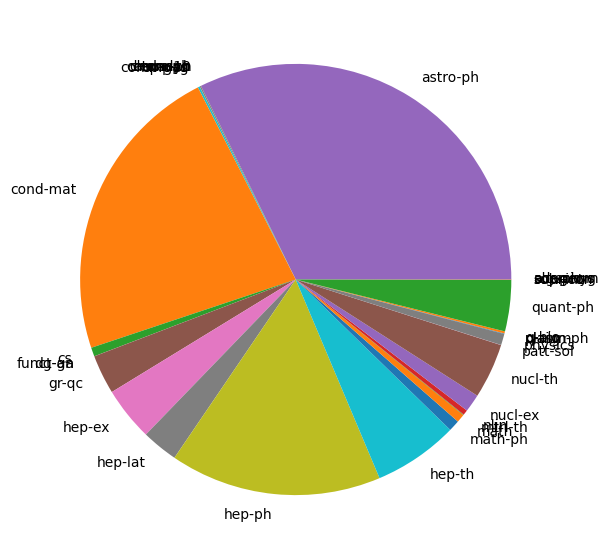

In [29]:
from matplotlib import pyplot as plt
import numpy as np
# Creating dataset
cars = keys
data = [flag_count[k] for k in keys]
# Creating plot
fig = plt.figure(figsize =(10, 7))
_=plt.pie(data, labels = cars)

### lets deal with the old arxiv code

In [15]:
import json
import pandas as pd

In [4]:
# metadata = pd.read_json("/nvme/zhangtianning/datasets/whole_arxiv_data/arxiv-metadata-snapshot.20231127//arxiv-metadata-snapshot.json",lines=True)

In [16]:
import os
from tqdm.auto import tqdm
already_downloads_1= os.listdir("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex")
already_downloads_2= os.listdir("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_text_tex/")
already_download = already_downloads_1 + already_downloads_2

In [17]:
should_download_pool    = {}
existed_arxivid_in_ceph = {
    'pass': [],
    'pdf' : [],
    'empty':[]
}
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/data/whole_file_path_in_arxiv",'r') as f:
    for line in f:
        dest_name = line.strip()
        size="1"
        if len(dest_name.split())>1:
            size, dest_name = dest_name.split()
        real_name = os.path.basename(dest_name).replace('.tar', '').replace('.pdf', '')
        
        if size == "0" : 
            existed_arxivid_in_ceph['empty'].append(real_name)
            continue
        
        if dest_name.endswith('.pdf'):
            existed_arxivid_in_ceph['pdf'].append(real_name)
            continue
        if real_name not in should_download_pool:
            should_download_pool[real_name] = []
        should_download_pool[real_name].append(dest_name)
        existed_arxivid_in_ceph['pass'].append(real_name)
should_download = list(should_download_pool.keys())
print(f"already_download: {len(already_download)}: {already_download[:10]}")
print(f"should_download: {len(should_download)}: {should_download[:10]}")
remain_download = set(should_download) - set(already_download)
print(f"remain download: {len(remain_download)}")

for k,v in existed_arxivid_in_ceph.items():
    if isinstance(v, list):
        print(f"{k}=>{len(v)}")
    else:
        print(f"{k}=>{v}")


already_download: 1773428: ['1211.4645', '1706.07881', '1012.5997', '2009.07773', '2102.00940', '1002.3185', '2303.04165', '1411.3702', '1404.5086', '1403.3873']
should_download: 2097592: ['0704.0001', '0704.0006', '0704.0007', '0704.0008', '0704.0009', '0704.0015', '0704.0016', '0704.0017', '0704.0018', '0704.0020']
remain download: 324164
pass=>2097605
pdf=>456450
empty=>15989


In [23]:
tex_status_metadata = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/tex_status.csv')
#xml_status_metadata = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/xml_status.csv')

/tmp/ipykernel_212067/106901514.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  tex_status_metadata = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/tex_status.csv')


In [26]:
df = tex_status_metadata

In [30]:
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/donetxt.txt",'r') as f:
    arxivids = [t.strip() for t in f.readlines()]

In [31]:
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/data/whole_file_path_in_arxiv.remain",'w') as f:
    for arxivid in arxivids:
        f.write(should_download_pool[arxivid][0]+'\n')

In [29]:
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/data/whole_file_path_in_arxiv.remain",'w') as f:
    for arxivid in df[df['_type']=='tex'].arxiv_id:
        f.write(should_download_pool[arxivid][0]+'\n')

In [7]:
import shutil
import os

In [8]:

for arxvid in arxvids:
    assert arxvid
    arvidpath = os.path.join("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex", arxvid)
    if not os.path.exists(arvidpath):continue
    shutil.rmtree(arvidpath)
    #os.system(f"rm -r /nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/unprocessed_tex/{arxvid}")

In [10]:
import pandas as pd
xml_status_metadata = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/xml_status.csv')

/tmp/ipykernel_212067/3982325173.py:2: DtypeWarning: Columns (2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  xml_status_metadata = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/xml_status.csv')


In [10]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/data/whole_file_path_in_arxiv.remain','w') as f:
    for t in arxvids:
        f.write(should_download_pool[t][0]+'\n')

In [28]:
existed_arxivid_in_ceph   = set(existed_arxivid_in_ceph)
whole_arxiv_id_in_metadata= set(whole_arxiv_id_in_metadata)

In [29]:
arxiv_id_that_wont_in_our_system = whole_arxiv_id_in_metadata - existed_arxivid_in_ceph

In [30]:
arxiv_id_that_beyound_remote = existed_arxivid_in_ceph - whole_arxiv_id_in_metadata 

In [67]:
### lets format the table
uparxive_processing_metadata = {}

for arxivid in already_downloads_1:
    uparxive_processing_metadata[arxivid] = {'register': True, '_type': 'tex'}
for arxivid in already_downloads_2:
    uparxive_processing_metadata[arxivid] = {'register': True, '_type': 'plain_tex'}
print(len(uparxive_processing_metadata))

1881715


In [51]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/data/fail_collection.reason','r') as f:
    for line in f:
        arxivid, _type = line.strip().split()
        uparxive_processing_metadata[arxivid] = {'register': True, '_type': _type}
print(len(uparxive_processing_metadata))

2016350


In [68]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/data/fail_collection2.reason','r') as f:
    for line in f:
        arxivid, _type = line.strip().split()
        uparxive_processing_metadata[arxivid] = {'register': True, '_type': _type}
print(len(uparxive_processing_metadata))

2081449


In [73]:
for arxivid in arxiv_id_that_wont_in_our_system:
    uparxive_processing_metadata[arxivid] = {'register': False}
print(len(uparxive_processing_metadata))

2362253


In [71]:
## basicly is the PDF part, may 

failed_download = set(should_download) - set(uparxive_processing_metadata) 
print(len(failed_download))
for arxivid in failed_download:
    uparxive_processing_metadata[arxivid] = {'register': True, '_type': 'noTeX'}

16143


In [65]:
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/data/whole_file_path_in_arxiv.remain','w') as f:
    for i, arxivid in enumerate(failed_download):
        f.write(should_download_pool[arxivid][0]+'\n') 

In [64]:
should_download_pool[arxivid]

['add_45w/1402.3274/1402.3274.tar']

In [74]:
uparxive_processing_metadata_line = [{'arxiv_id': arxiv_id}|val for arxiv_id,val in uparxive_processing_metadata.items()]
metadata = pd.DataFrame(uparxive_processing_metadata_line)

In [75]:
metadata.to_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/tex_status.csv')

In [ ]:
arxvids

In [1]:
metadata.

2305.13673

In [70]:
for i, t in enumerate(failed_download):
    print(should_download_pool[t])
    if i>10:break
        

['1508.03750']
['add_45w/math_9806061/math_9806061.tar']
['add_45w/1202.6343/1202.6343.tar']
['add_45w/1402.3274/1402.3274.tar']
['quant-ph_9812082']
['hep-ph_9507280']
['solv-int_9804006']
['hep-th_9205047']
['0709.3460']
['add_45w/2205.14730/2205.14730.tar']
['add_45w/1905.13270/1905.13270.tar']
['hep-ph_0608304']


In [ ]:
whole_arxiv_id_in_metadata  = metadata['arxiv_id_in_ceph.txt.remain']

In [38]:
# flag_count={}
# for flag in tqdm(metadata.id):
#     if len(flag)>4 and  flag[4] == '.':
#         continue
#     if "_" not in flag:continue
#     flag = flag.split('_')[0]
#     if flag not in flag_count:
#         #print(line)
#         flag_count[flag]=0
#     flag_count[flag]+=1

  0%|          | 0/2370685 [00:00<?, ?it/s]

In [6]:
categories_pool = {}
for categories,_id in metadata[['categories','id']].values:
    for categorie in categories.split():
        categorie = categorie.strip()
        if categorie not in categories_pool:categories_pool[categorie] = []
        categories_pool[categorie].append(_id)

In [8]:
metadata['categories']

0                                           physics.class-ph
1               physics.comp-ph cond-mat.soft physics.bio-ph
2                                                    math.AP
3                            hep-th cond-mat.stat-mech gr-qc
4          cond-mat.quant-gas cond-mat.str-el cond-mat.su...
                                 ...                        
2370680                                                gr-qc
2370681                                 physics.soc-ph cs.SI
2370682                                              math.NT
2370683                     cond-mat.mtrl-sci physics.optics
2370684                             gr-qc astro-ph.EP hep-ph
Name: categories, Length: 2370685, dtype: object

In [9]:
categories_count = {}
for categories in metadata.categories:
    for categorie in categories.split():
        categorie = categorie.strip()
        if categorie not in categories_count:categories_count[categorie] = 0
        categories_count[categorie]+=1

In [10]:
# with open("/nvme/zhangtianning/datasets/whole_arxiv_data/arxiv-metadata-snapshot.20231127/categories_count.json", 'w') as f:
#     json.dump(categories_count,f)

In [11]:
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/arxiv-metadata-snapshot.20231127/categories_count.json", 'r') as f:
    categories_count = json.load(f)

In [15]:
# from matplotlib import pyplot as plt
# import numpy as np
# # Creating dataset
# keys = list(categories_count.keys())
# data = [categories_count[k] for k in keys]
# # Creating plot
# fig = plt.figure(figsize =(10, 7))
# _=plt.pie(data, labels = keys)

In [28]:
new_categories_count={}
for k, d in categories_count.items():
    real_name = k.split('.')[0]
    if real_name not in new_categories_count:new_categories_count[real_name] = 0
    new_categories_count[real_name]=+d

In [29]:
new_categories_count

{'physics': 3670,
 'cond-mat': 14215,
 'math': 3480,
 'hep-th': 162079,
 'gr-qc': 103494,
 'astro-ph': 105380,
 'hep-ex': 51928,
 'quant-ph': 141289,
 'hep-ph': 175652,
 'stat': 7710,
 'nucl-th': 55577,
 'hep-lat': 27204,
 'nlin': 1466,
 'q-bio': 1356,
 'nucl-ex': 25030,
 'math-ph': 76640,
 'cs': 3751,
 'q-fin': 2123,
 'comp-gas': 221,
 'chao-dyn': 2398,
 'patt-sol': 650,
 'q-alg': 1578,
 'atom-ph': 123,
 'plasm-ph': 38,
 'alg-geom': 1423,
 'solv-int': 1413,
 'adap-org': 584,
 'supr-con': 175,
 'acc-phys': 49,
 'funct-an': 427,
 'chem-ph': 251,
 'dg-ga': 732,
 'mtrl-th': 262,
 'bayes-an': 16,
 'cmp-lg': 894,
 'ao-sci': 17,
 'eess': 13017,
 'econ': 3545}

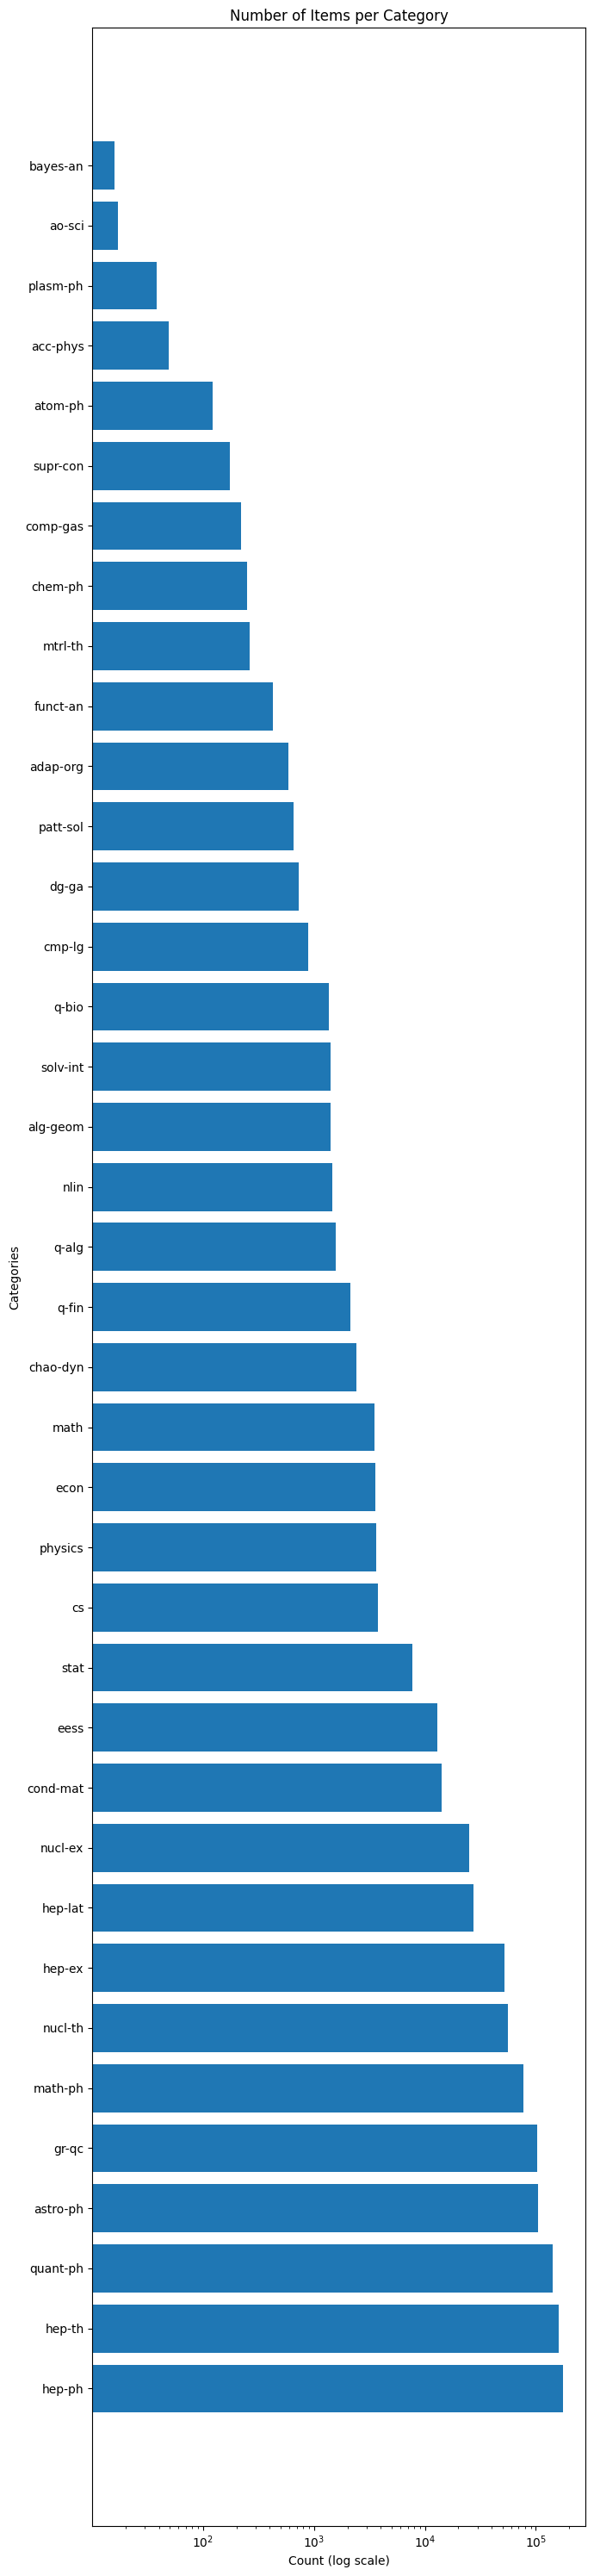

In [30]:
from matplotlib import pyplot as plt
import numpy as np

# Creating dataset
keys = list(new_categories_count.keys())
data = [new_categories_count[k] for k in keys]

# Sorting the data and keys based on the values in descending order
sorted_data, sorted_keys = zip(*sorted(zip(data, keys), reverse=True))

# Creating plot
fig, ax = plt.subplots(figsize=(7, 30))
y = np.arange(len(sorted_keys))
ax.barh(y, sorted_data)

# Set the y-tick labels to the sorted keys
ax.set_yticks(y)
ax.set_yticklabels(sorted_keys)

# Set the x-axis to log scale
ax.set_xscale('log')

# Add labels and title
ax.set_ylabel('Categories')
ax.set_xlabel('Count (log scale)')
ax.set_title('Number of Items per Category')

# Adjust the layout to prevent overlapping y-tick labels
plt.tight_layout()

# Display the plot
plt.show()
fig.savefig('/nvme/zhangtianning/datasets/whole_arxiv_data/arxiv-metadata-snapshot.20231127/categories_count.general_cata.png',dpi=300)

### obtain files exclude CS and quant-ph

In [39]:
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_cs/whole_id_in_arxiv_metadata.json",'r') as f:
    exclude_cs_pool = json.load(f)
    exclude_cs_pool = set(list(exclude_cs_pool.keys()))

In [37]:
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_old_quant_ph/old_arxiv_id_in_ceph.txt", 'r') as f:
    exclude_old_quant_ph_list = set([t.strip().split('.')[0] for t in f.readlines()])

In [42]:
import os
exclude_quant_ph_list = set(os.listdir("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_quant_ph/"))

In [43]:
exclude_pool = exclude_cs_pool|exclude_old_quant_ph_list|exclude_quant_ph_list

In [249]:
from tqdm.auto import tqdm
should_download_paths =[]
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_file_path_in_arxiv",'r') as f:
    for i,line in tqdm(enumerate(f),total=25044651):
        if '.pdf' in line:continue
        if "/" not in line:continue
        flag = line.strip().split('/')[0]
        flag = flag.strip().split()[-1]
        should_download_paths.append(line.strip().split()[-1])

  0%|          | 0/25044651 [00:00<?, ?it/s]

In [252]:
should_download_paths[2]

'0704.0001/eps/14000_atlas_delphi_qqgg_resfox_db12.eps'

In [49]:
os.makedirs('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files')

In [6]:
should_download_paths = []
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/arxiv_id_in_ceph.txt.remain",'r') as f:
    for line in f:
        should_download_paths.append(line)

In [11]:
len(should_download_paths)

1284259

In [10]:
t.split('/')[0] for t in 

'0906.3589'

In [50]:
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/arxiv_id_in_ceph.txt",'w') as f:
    for line in should_download_paths:
        f.write(line+"\n")

In [2]:
should_download_paths = []
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/arxiv_id_in_ceph.txt.remain",'r') as f:
    for line in f:
        should_download_paths.append(line)

len(should_download_paths)

import numpy as np

should_download_paths = np.array(should_download_paths)

partitions = np.array_split(should_download_paths, 1000)

import os
os.makedirs('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/arxiv_id_in_ceph_list',exist_ok=True)

for i, partition in enumerate(partitions):
    with open(f"/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/arxiv_id_in_ceph_list/partition_{i:03d}.txt",'w') as f:
        for line in partition:
            f.write(line+"\n")

### obtain cs

In [62]:
cs_flag_list=['cs.SD','cs.LG','cs.MM','cs.CC','cs.DS','cs.CE','cs.DL','cs.CV','cs.LO','cs.DC','cs.RO','cs.IT','cs.DB','cs.SI','cs.NI','cs.CL','cs.DM','cs.IR','cs.HC','cs.AI','cs.CY','cs.CR','cs.NE','cs.SE','cs.SY','cs.GT','cs.GL','cs.NA','cs.FL','cs.GR','cs.CG','cs.PL','cs.MA','cs.AR','cs.OS','cs.MS','cs.OH','cs.PF','cs.SC','cs.ET']

In [65]:
cs_old_arxiv_code = []
for cs_flag in cs_flag_list:
    cs_old_arxiv_code+=categories_pool[cs_flag]
cs_old_arxiv_code={k:1 for k in cs_old_arxiv_code}

In [32]:
with open("/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_cs/whole_id_in_arxiv_metadata.json",'r') as f:
    cs_old_arxiv_code = json.load(f)

In [66]:
with open("data/whole_arxiv_all_cs/whole_id_in_arxiv_metadata.json",'w') as f:
    json.dump(cs_old_arxiv_code,f)

In [67]:
flag_count = {}
with open("data/whole_file_path_in_arxiv",'r') as f:
    for i,line in tqdm(enumerate(f),total=25044651):
        if '.pdf' in line:continue
        if "/" not in line:continue
        flag = line.strip().split('/')[0]
        flag = flag.strip().split()[-1]
#         if len(flag)>4 and  flag[4] == '.':
#             continue
#         if "_" not in flag:continue
#         flag = flag.split('_')[0]
        if flag not in flag_count:
            flag_count[flag]=0
        flag_count[flag]+=1

  0%|          | 0/25044651 [00:00<?, ?it/s]

In [69]:
whole_arxiv_id_in_ceph = flag_count

In [70]:
with open("data/whole_arxiv_id_in_ceph.json",'w') as f:
    json.dump(whole_arxiv_id_in_ceph,f)

In [71]:
whole_arxiv_id_in_ceph = set(whole_arxiv_id_in_ceph.keys())
whole_id_in_arxiv_metadata = set(cs_old_arxiv_code.keys())

In [72]:
arxiv_id_for_cs_in_ceph = whole_arxiv_id_in_ceph.intersection(whole_id_in_arxiv_metadata)

In [82]:
should_download_paths =[]
with open("data/whole_file_path_in_arxiv",'r') as f:
    for i,line in tqdm(enumerate(f),total=25044651):
        if '.pdf' in line:continue
        if "/" not in line:continue
        flag = line.strip().split('/')[0]
        flag = flag.strip().split()[-1]
        if flag in arxiv_id_for_cs_in_ceph:
            should_download_paths.append(line.strip().split()[-1])

  0%|          | 0/25044651 [00:00<?, ?it/s]

In [90]:
with open("data/whole_arxiv_all_cs/cs_id_in_ceph.txt",'w') as f:
    for line in should_download_paths:
        f.write(line+"\n")

In [79]:
aaaa = []
for key in whole_arxiv_id_in_ceph:
    #if 'cs.' not in key:continue
    if 'ph-' not in key:continue
    aaaa.append(key)

In [81]:
len(flag_count)

1506936

In [26]:
should_download_paths = []
with open("data/whole_arxiv_all_cs/cs_id_in_ceph.txt",'r') as f:
    for line in f:
        should_download_paths.append(line)

len(should_download_paths)

import numpy as np

should_download_paths = np.array(should_download_paths)

partitions = np.array_split(should_download_paths, 1000)

import os
os.makedirs('/nas/zhangtianning.di/datasets/arxiv/whole_arxiv_all_cs/arxiv_id_in_ceph_list')

for i, partition in enumerate(partitions):
    with open(f"/nas/zhangtianning.di/datasets/arxiv/whole_arxiv_all_cs/arxiv_id_in_ceph_list/partition_{i:03d}.txt",'w') as f:
        for line in partition:
            f.write(line+"\n")

### obtain quant-ph

In [93]:
flag_list = ['quant-ph']

In [94]:
old_arxiv_code = []
for flag in flag_list:
    old_arxiv_code+=categories_pool[flag]
old_arxiv_code={k:1 for k in old_arxiv_code}

In [ ]:
with open("data/whole_arxiv_quant_ph/cs_id_in_ceph.txt",'w') as f:
    for line in should_download_paths:
        f.write(line+"\n")

In [96]:
# whole_arxiv_id_in_ceph = set(whole_arxiv_id_in_ceph.keys())
whole_id_in_arxiv_metadata = set(old_arxiv_code.keys())

In [97]:
arxiv_id_in_ceph = whole_arxiv_id_in_ceph.intersection(whole_id_in_arxiv_metadata)

In [101]:
len(whole_arxiv_id_in_ceph)

1506936

In [102]:
len(whole_id_in_arxiv_metadata)

141289

In [99]:
should_download_paths =[]
with open("data/whole_file_path_in_arxiv",'r') as f:
    for i,line in tqdm(enumerate(f),total=25044651):
        if '.pdf' in line:continue
        if "/" not in line:continue
        flag = line.strip().split('/')[0]
        flag = flag.strip().split()[-1]
        if flag in arxiv_id_in_ceph:
            should_download_paths.append(line.strip().split()[-1])

  0%|          | 0/25044651 [00:00<?, ?it/s]

In [103]:
with open("data/whole_arxiv_quant_ph/old_arxiv_id_in_ceph.txt",'w') as f:
    for line in should_download_paths:
        f.write(line+"\n")

In [2]:
%cd ../

/home/zhangtianning.di/projects_local/unarXive/src
